In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Checking column consistency across datasets
import os

folder_path = 'C:\\Users\\KIIT0001\\Downloads\\Capstone Project\\Datasets'

files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

for f in files:
    df_temp = pd.read_csv(os.path.join(folder_path, f), nrows=5)
    print(f, list(df_temp.columns))

T_ONTIME_REPORTING April 25.csv ['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
T_ONTIME_REPORTING Aug 24.csv ['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLE

In [3]:
import glob

all_files = glob.glob("C:\\Users\\KIIT0001\\Downloads\\Capstone Project\\Datasets/*.csv")

df_list = []

for file in all_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

In [4]:
df.shape

(10037057, 38)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10037057 entries, 0 to 10037056
Data columns (total 38 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY_OF_MONTH         int64  
 3   DAY_OF_WEEK          int64  
 4   FL_DATE              object 
 5   OP_UNIQUE_CARRIER    object 
 6   TAIL_NUM             object 
 7   OP_CARRIER_FL_NUM    float64
 8   ORIGIN_AIRPORT_ID    int64  
 9   ORIGIN               object 
 10  DEST_AIRPORT_ID      int64  
 11  DEST                 object 
 12  CRS_DEP_TIME         int64  
 13  DEP_TIME             float64
 14  DEP_DELAY            float64
 15  DEP_DELAY_NEW        float64
 16  DEP_DEL15            float64
 17  TAXI_OUT             float64
 18  WHEELS_OFF           float64
 19  WHEELS_ON            float64
 20  TAXI_IN              float64
 21  CRS_ARR_TIME         int64  
 22  ARR_TIME             float64
 23  ARR_DELAY            float64
 

In [6]:
# Top airlines by total flight
top_airlines = (
    df['OP_UNIQUE_CARRIER']
    .value_counts()
    .head(10)
    .index
)

df = df[df['OP_UNIQUE_CARRIER'].isin(top_airlines)]

In [7]:
# ==========================
# Compute total traffic per airport
# ==========================

# Count departures
origin_counts = df['ORIGIN'].value_counts()

# Count arrivals
dest_counts = df['DEST'].value_counts()

# Combine departures + arrivals
total_airport_traffic = origin_counts.add(dest_counts, fill_value=0)

# ==========================
# Extract Top 10 busiest airports
# ==========================

top_airports = (
    total_airport_traffic
    .sort_values(ascending=False)
    .head(10)
    .index
)

print("\nTop 10 Busiest Airports:")
print(top_airports.tolist())

# ==========================
# Filter dataset to keep only Top 10 airports
# (Hub-to-Hub flights only)
# ==========================

df_filtered = df[
    (df['ORIGIN'].isin(top_airports)) &
    (df['DEST'].isin(top_airports))
].copy()

print("\nOriginal dataset shape:", df.shape)
print("Filtered dataset shape:", df_filtered.shape)

# ==========================
# Verify airport distribution
# ==========================

print("\nFiltered Airport Distribution:")
print(df_filtered['ORIGIN'].value_counts())


# Top 10 airlines were initially selected. After restricting to hub-to-hub network flights, 9 airlines remained with significant operational presence.


Top 10 Busiest Airports:
['ORD', 'DFW', 'DEN', 'ATL', 'CLT', 'PHX', 'LAX', 'SEA', 'LAS', 'DCA']

Original dataset shape: (9044432, 38)
Filtered dataset shape: (582632, 38)

Filtered Airport Distribution:
ORIGIN
ORD    70806
LAX    69674
DEN    65185
PHX    63166
ATL    61701
DFW    61426
SEA    59979
LAS    56142
CLT    39727
DCA    34826
Name: count, dtype: int64


In [8]:
print("Airlines:", df['OP_UNIQUE_CARRIER'].unique())
print("Count:", df['OP_UNIQUE_CARRIER'].nunique())

Airlines: ['AA' 'AS' 'B6' 'DL' 'MQ' 'OH' 'OO' 'UA' 'WN' 'YX']
Count: 10


In [9]:
print("Airlines after airport filtering:",
      df_filtered['OP_UNIQUE_CARRIER'].nunique())

Airlines after airport filtering: 9


In [10]:
df_filtered.head()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
44,2025,4,1,2,4/1/2025 12:00:00 AM,AA,N109UW,2999.0,13930,ORD,...,0.0,110.0,104.0,76.0,612.0,0.0,0.0,0.0,0.0,220.0
69,2025,4,1,2,4/1/2025 12:00:00 AM,AA,N115NN,2749.0,11298,DFW,...,0.0,125.0,131.0,91.0,731.0,NaN,NaN,NaN,NaN,NaN
80,2025,4,1,2,4/1/2025 12:00:00 AM,AA,N118NN,2091.0,12892,LAX,...,0.0,186.0,163.0,142.0,1235.0,NaN,NaN,NaN,NaN,NaN
94,2025,4,1,2,4/1/2025 12:00:00 AM,AA,N120EE,2024.0,12892,LAX,...,0.0,185.0,224.0,143.0,1235.0,0.0,0.0,31.0,0.0,0.0
95,2025,4,1,2,4/1/2025 12:00:00 AM,AA,N120EE,3334.0,11298,DFW,...,0.0,208.0,217.0,190.0,1235.0,NaN,NaN,NaN,NaN,NaN


In [11]:
df_filtered['FL_DATE'] = pd.to_datetime(df_filtered['FL_DATE'])

In [12]:
df_filtered = df_filtered.drop(columns=['YEAR','MONTH','DAY_OF_MONTH'])

In [13]:
df_filtered.shape

(582632, 35)

In [14]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 582632 entries, 44 to 10036574
Data columns (total 35 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DAY_OF_WEEK          582632 non-null  int64         
 1   FL_DATE              582632 non-null  datetime64[ns]
 2   OP_UNIQUE_CARRIER    582632 non-null  object        
 3   TAIL_NUM             581779 non-null  object        
 4   OP_CARRIER_FL_NUM    582632 non-null  float64       
 5   ORIGIN_AIRPORT_ID    582632 non-null  int64         
 6   ORIGIN               582632 non-null  object        
 7   DEST_AIRPORT_ID      582632 non-null  int64         
 8   DEST                 582632 non-null  object        
 9   CRS_DEP_TIME         582632 non-null  int64         
 10  DEP_TIME             575920 non-null  float64       
 11  DEP_DELAY            575915 non-null  float64       
 12  DEP_DELAY_NEW        575915 non-null  float64       
 13  DEP_DEL15       

In [15]:
df_filtered.describe()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,...,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,582632.000000,582632,582632.000000,582632.000000,582632.000000,582632.000000,575920.000000,575915.000000,575915.000000,575915.000000,...,582632.000000,582632.000000,574047.000000,574047.000000,582632.000000,126551.000000,126551.000000,126551.000000,126551.000000,126551.000000
mean,3.990931,2025-03-15 19:20:03.048236800,1795.533891,12507.665959,12507.215560,1317.129773,1317.307713,13.716502,16.556492,0.219171,...,0.002712,172.942144,167.033098,137.181119,1029.399612,23.652504,3.244463,13.993102,0.101445,28.808725
min,1.000000,2024-07-01 00:00:00,1.000000,10397.000000,10397.000000,5.000000,1.000000,-33.000000,0.000000,0.000000,...,0.000000,62.000000,46.000000,21.000000,226.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2024-11-04 00:00:00,767.000000,11292.000000,11292.000000,858.000000,854.000000,-5.000000,0.000000,0.000000,...,0.000000,122.000000,116.000000,87.000000,606.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,2025-03-19 00:00:00,1585.000000,12889.000000,12889.000000,1315.000000,1317.000000,-1.000000,0.000000,0.000000,...,0.000000,164.000000,157.000000,125.000000,888.000000,3.000000,0.000000,2.000000,0.000000,2.000000
75%,6.000000,2025-07-22 00:00:00,2530.000000,13930.000000,13930.000000,1735.000000,1743.000000,11.000000,11.000000,0.000000,...,0.000000,224.000000,215.000000,185.000000,1440.000000,21.000000,0.000000,18.000000,0.000000,33.000000
max,7.000000,2025-11-30 00:00:00,8819.000000,14747.000000,14747.000000,2359.000000,2400.000000,2446.000000,2446.000000,1.000000,...,1.000000,376.000000,523.000000,382.000000,2329.000000,2353.000000,1188.000000,1158.000000,512.000000,2417.000000
std,2.009264,NaN,1245.888675,1447.874470,1447.769779,504.658231,523.640479,56.431758,55.489130,0.413685,...,0.052005,66.184756,66.653238,64.710212,546.413209,72.349426,26.758253,29.447017,2.833116,67.040520


## Missing Value Treatment

In [17]:
missing = df_filtered.isnull().sum()
missing[missing > 0]

TAIL_NUM                  853
DEP_TIME                 6712
DEP_DELAY                6717
DEP_DELAY_NEW            6717
DEP_DEL15                6717
TAXI_OUT                 6981
WHEELS_OFF               6981
WHEELS_ON                7078
TAXI_IN                  7078
ARR_TIME                 7078
ARR_DELAY                8585
ARR_DELAY_NEW            8585
ARR_DEL15                8585
CANCELLATION_CODE      575627
ACTUAL_ELAPSED_TIME      8585
AIR_TIME                 8585
CARRIER_DELAY          456081
WEATHER_DELAY          456081
NAS_DELAY              456081
SECURITY_DELAY         456081
LATE_AIRCRAFT_DELAY    456081
dtype: int64

In [18]:
# ----------------------------
# 1. Cancellation Code
# ----------------------------
df_filtered['CANCELLATION_CODE'] = df_filtered['CANCELLATION_CODE'].fillna('Not Cancelled')


# ----------------------------
# 2. Delay Cause Columns
# (Valid to fill 0 — domain rule)
# ----------------------------
delay_cols = [
    'CARRIER_DELAY','WEATHER_DELAY',
    'NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY'
]

df_filtered[delay_cols] = df_filtered[delay_cols].fillna(0)


# ----------------------------
# 3. Cancelled Flights → No departure / arrival happened
# (Structural missingness — not data error)
# ----------------------------

cancel_mask = df_filtered['CANCELLED'] == 1

# If cancelled → no departure delay or arrival delay
df_filtered.loc[cancel_mask, ['ARR_DELAY','DEP_DELAY']] = 0

# If cancelled → operational time metrics are structurally zero
operational_cols = [
    'DEP_TIME','TAXI_OUT','WHEELS_OFF',
    'WHEELS_ON','TAXI_IN','ARR_TIME',
    'ACTUAL_ELAPSED_TIME','AIR_TIME',
    'DEP_DELAY_NEW','DEP_DEL15',
    'ARR_DELAY_NEW','ARR_DEL15'
]

df_filtered.loc[cancel_mask, operational_cols] = 0


# ----------------------------
# 4. Tail Number
# (Data availability issue, not structural)
# ----------------------------
df_filtered['TAIL_NUM'] = df_filtered['TAIL_NUM'].fillna('Unknown')


# ----------------------------
# 5. Final Check
# ----------------------------
missing = df_filtered.isnull().sum()
missing[missing > 0]

WHEELS_ON                73
TAXI_IN                  73
ARR_TIME                 73
ARR_DELAY              1580
ARR_DELAY_NEW          1580
ARR_DEL15              1580
ACTUAL_ELAPSED_TIME    1580
AIR_TIME               1580
dtype: int64

In [19]:
# ----------------------------
# 6. Diverted Flights → Arrival metrics undefined
# ----------------------------

divert_mask = df_filtered['DIVERTED'] == 1

arrival_cols = [
    'WHEELS_ON',
    'TAXI_IN',
    'ARR_TIME',
    'ARR_DELAY',
    'ARR_DELAY_NEW',
    'ARR_DEL15',
    'ACTUAL_ELAPSED_TIME',
    'AIR_TIME'
]

df_filtered.loc[divert_mask, arrival_cols] = 0

missing = df_filtered.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [20]:
df_filtered.isnull().sum()

DAY_OF_WEEK            0
FL_DATE                0
OP_UNIQUE_CARRIER      0
TAIL_NUM               0
OP_CARRIER_FL_NUM      0
ORIGIN_AIRPORT_ID      0
ORIGIN                 0
DEST_AIRPORT_ID        0
DEST                   0
CRS_DEP_TIME           0
DEP_TIME               0
DEP_DELAY              0
DEP_DELAY_NEW          0
DEP_DEL15              0
TAXI_OUT               0
WHEELS_OFF             0
WHEELS_ON              0
TAXI_IN                0
CRS_ARR_TIME           0
ARR_TIME               0
ARR_DELAY              0
ARR_DELAY_NEW          0
ARR_DEL15              0
CANCELLED              0
CANCELLATION_CODE      0
DIVERTED               0
CRS_ELAPSED_TIME       0
ACTUAL_ELAPSED_TIME    0
AIR_TIME               0
DISTANCE               0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64

## Duplicate check

In [22]:
duplicates = df_filtered.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


## Separate Numeric and Categorical columns

In [24]:
numeric_cols = df_filtered.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df_filtered.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 29
Categorical Columns: 5


## Outliers Check and Decision to Keep / Remove them

In [26]:
# Remove binary/indicator variables from outlier check
binary_like = ['CANCELLED','DIVERTED','DEP_DEL15','ARR_DEL15']
numeric_for_outlier = [col for col in numeric_cols if col not in binary_like]

# ----------------------------
# IQR Outlier Detection
# ----------------------------
outlier_summary = {}

for col in numeric_for_outlier:
    Q1 = df_filtered[col].quantile(0.25)
    Q3 = df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_filtered[
        (df_filtered[col] < lower_bound) |
        (df_filtered[col] > upper_bound)
    ].shape[0]
    
    outlier_summary[col] = outliers

outlier_summary

{'DAY_OF_WEEK': 0,
 'OP_CARRIER_FL_NUM': 13944,
 'ORIGIN_AIRPORT_ID': 0,
 'DEST_AIRPORT_ID': 0,
 'CRS_DEP_TIME': 0,
 'DEP_TIME': 0,
 'DEP_DELAY': 76295,
 'DEP_DELAY_NEW': 91101,
 'TAXI_OUT': 38287,
 'WHEELS_OFF': 0,
 'WHEELS_ON': 0,
 'TAXI_IN': 36628,
 'CRS_ARR_TIME': 0,
 'ARR_TIME': 0,
 'ARR_DELAY': 54488,
 'ARR_DELAY_NEW': 90969,
 'CRS_ELAPSED_TIME': 0,
 'ACTUAL_ELAPSED_TIME': 805,
 'AIR_TIME': 364,
 'DISTANCE': 0,
 'CARRIER_DELAY': 70920,
 'WEATHER_DELAY': 6830,
 'NAS_DELAY': 65737,
 'SECURITY_DELAY': 447,
 'LATE_AIRCRAFT_DELAY': 64235}

In [27]:
# -------------------------------------------------------------------
# OUTLIER TREATMENT DECISION
# -------------------------------------------------------------------
# We intentionally DO NOT cap or remove outliers because:
#
# 1. In aviation operations, extreme delays are real events,
#    not data errors (e.g., weather disruption, ATC congestion).
#
# 2. Removing or capping them would distort operational risk modeling.
#
# 3. Tree-based models (RF, GB, XGBoost) are robust to extreme values.
#
# 4. Extreme delay values are highly informative for predicting
#    systemic disruption and cancellation cascades.
#
# Therefore, outliers are retained as valid business signals.
# -------------------------------------------------------------------

## Number of classes in each category and identifying the unique classes

In [29]:
for i in df_filtered[categorical_cols]:
    print(f'The number of unique classes of {i} are:', df_filtered[i].nunique())
    print(df_filtered[i].unique())
    print('----------------------------------------------------------')

The number of unique classes of OP_UNIQUE_CARRIER are: 9
['AA' 'AS' 'DL' 'MQ' 'OH' 'OO' 'UA' 'WN' 'YX']
----------------------------------------------------------
The number of unique classes of TAIL_NUM are: 4818
['N109UW' 'N115NN' 'N118NN' ... 'N27903' 'N28987' 'N958DZ']
----------------------------------------------------------
The number of unique classes of ORIGIN are: 10
['ORD' 'DFW' 'LAX' 'CLT' 'DEN' 'PHX' 'SEA' 'ATL' 'LAS' 'DCA']
----------------------------------------------------------
The number of unique classes of DEST are: 10
['DCA' 'ATL' 'DFW' 'LAX' 'PHX' 'LAS' 'CLT' 'DEN' 'SEA' 'ORD']
----------------------------------------------------------
The number of unique classes of CANCELLATION_CODE are: 4
['Not Cancelled' 'A' 'B' 'C']
----------------------------------------------------------


In [30]:
for i in df_filtered[numeric_cols]:
    print(f'The number of unique classes of {i} are:', df_filtered[i].nunique())
    print(df_filtered[i].unique())
    print('----------------------------------------------------------')

The number of unique classes of DAY_OF_WEEK are: 7
[2 3 4 5 6 7 1]
----------------------------------------------------------
The number of unique classes of OP_CARRIER_FL_NUM are: 4401
[2999. 2749. 2091. ... 6583. 6584. 6587.]
----------------------------------------------------------
The number of unique classes of ORIGIN_AIRPORT_ID are: 10
[13930 11298 12892 11057 11292 14107 14747 10397 12889 11278]
----------------------------------------------------------
The number of unique classes of DEST_AIRPORT_ID are: 10
[11278 10397 11298 12892 14107 12889 11057 11292 14747 13930]
----------------------------------------------------------
The number of unique classes of CRS_DEP_TIME are: 1189
[1604 2054 1115 ...   17 2204   42]
----------------------------------------------------------
The number of unique classes of DEP_TIME are: 1373
[1950. 2053. 1110. ...  438.  216.  254.]
----------------------------------------------------------
The number of unique classes of DEP_DELAY are: 1132
[ 2

## Multi-Class Target Definition (Using DEP_DEL15)

In [32]:
# Initialize as On-Time
df_filtered['flight_status'] = 0

# Delayed flights (not cancelled)
df_filtered.loc[
    (df_filtered['CANCELLED'] == 0) &
    (df_filtered['DEP_DEL15'] == 1),
    'flight_status'
] = 1

# Cancelled flights override
df_filtered.loc[
    df_filtered['CANCELLED'] == 1,
    'flight_status'
] = 2

In [33]:
# ---------------------------------------------------
# TARGET INTERPRETATION
# ---------------------------------------------------
# flight_status = 0 → On-Time Operations
# flight_status = 1 → Departure Delay >= 15 minutes
# flight_status = 2 → Cancelled Flight
#
# This converts the dataset into a real-world
# operational risk classification problem.
#
# Instead of predicting delay only, the model will
# predict overall disruption risk.
# ---------------------------------------------------

## Target Analysis

In [35]:
df_filtered['flight_status'].value_counts(normalize=True)

flight_status
0    0.771643
1    0.216334
2    0.012023
Name: proportion, dtype: float64

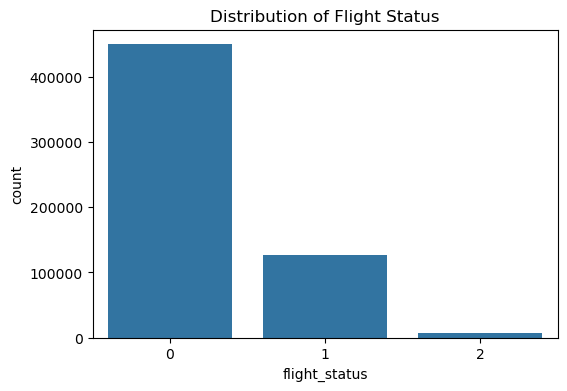

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x='flight_status', data=df_filtered)
plt.title("Distribution of Flight Status")
plt.show()

In [37]:
# Airline vs Target
airline_target = pd.crosstab(
    df_filtered['OP_UNIQUE_CARRIER'],
    df_filtered['flight_status'],
    normalize='index'
)

airline_target

flight_status,0,1,2
OP_UNIQUE_CARRIER,,,
AA,0.747666,0.235703,0.016631
AS,0.771673,0.219568,0.008759
DL,0.801228,0.188126,0.010646
MQ,0.796813,0.186006,0.017181
OH,0.736795,0.229530,0.033675
OO,0.854764,0.138840,0.006396
UA,0.818443,0.173624,0.007932
WN,0.711957,0.281048,0.006995
YX,0.809609,0.159057,0.031334


In [38]:
# Airport vs Target
airport_target = pd.crosstab(
    df_filtered['ORIGIN'],
    df_filtered['flight_status'],
    normalize='index'
)

airport_target

flight_status,0,1,2
ORIGIN,,,
ATL,0.766681,0.218489,0.014830
CLT,0.753946,0.232738,0.013316
DCA,0.783897,0.193562,0.022541
DEN,0.758518,0.232983,0.008499
DFW,0.696806,0.283219,0.019975
LAS,0.779399,0.210876,0.009725
LAX,0.813101,0.178618,0.008281
ORD,0.760698,0.226619,0.012683
PHX,0.805386,0.186366,0.008248


In [39]:
# Day of week vs Target
dow_target = pd.crosstab(
    df_filtered['DAY_OF_WEEK'],
    df_filtered['flight_status'],
    normalize='index'
)

dow_target

flight_status,0,1,2
DAY_OF_WEEK,,,
1,0.763496,0.225906,0.010598
2,0.807706,0.183749,0.008544
3,0.798559,0.192736,0.008705
4,0.761129,0.225688,0.013182
5,0.749877,0.232537,0.017586
6,0.781129,0.206031,0.012840
7,0.744519,0.243041,0.012440


In [40]:
# Distance vs Target
df_filtered.groupby('flight_status')['DISTANCE'].describe()

,count,mean,std,min,25%,50%,75%,max
flight_status,,,,,,,,
0,449584.0,1033.283976,549.917821,226.0,606.0,888.0,1476.0,2329.0
1,126043.0,1018.950350,535.418800,226.0,606.0,888.0,1440.0,2329.0
2,7005.0,968.116060,509.289865,226.0,606.0,867.0,1235.0,2329.0


## FEATURE ENGINEERING PLAN

In [42]:
# ============================================================
# 1️⃣ Ensure Full Chronological Sorting
# ============================================================

df_filtered = df_filtered.sort_values(
    ['TAIL_NUM', 'FL_DATE', 'CRS_DEP_TIME']
)


# ============================================================
# 2️⃣ Rolling Airline Delay Rate (Last 7 Flights)
# ============================================================

df_filtered = df_filtered.sort_values(['OP_UNIQUE_CARRIER', 'FL_DATE', 'CRS_DEP_TIME'])

df_filtered['airline_delay_rate_7f'] = (
    df_filtered
    .groupby('OP_UNIQUE_CARRIER')['DEP_DEL15']
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_filtered['airline_delay_rate_7f'] = df_filtered['airline_delay_rate_7f'].fillna(0)


# ============================================================
# 3️⃣ Rolling Airline Cancellation Rate (Last 7 Flights)
# ============================================================

df_filtered['airline_cancel_rate_7f'] = (
    df_filtered
    .groupby('OP_UNIQUE_CARRIER')['CANCELLED']
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_filtered['airline_cancel_rate_7f'] = df_filtered['airline_cancel_rate_7f'].fillna(0)


# ============================================================
# 4️⃣ Rolling Airport Delay Rate (Origin)
# ============================================================

df_filtered = df_filtered.sort_values(['ORIGIN', 'FL_DATE', 'CRS_DEP_TIME'])

df_filtered['airport_delay_rate_7f'] = (
    df_filtered
    .groupby('ORIGIN')['DEP_DEL15']
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_filtered['airport_delay_rate_7f'] = df_filtered['airport_delay_rate_7f'].fillna(0)


# ============================================================
# 5️⃣ Rolling Route Delay Rate
# ============================================================

df_filtered['route'] = df_filtered['ORIGIN'] + "_" + df_filtered['DEST']

df_filtered = df_filtered.sort_values(['route', 'FL_DATE', 'CRS_DEP_TIME'])

df_filtered['route_delay_rate_7f'] = (
    df_filtered
    .groupby('route')['DEP_DEL15']
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_filtered['route_delay_rate_7f'] = df_filtered['route_delay_rate_7f'].fillna(0)


# ============================================================
# 6️⃣ Aircraft Intelligence Layer (HIGH IMPACT)
# ============================================================

df_filtered = df_filtered.sort_values(['TAIL_NUM', 'FL_DATE', 'CRS_DEP_TIME'])

# --- Aircraft Rolling Delay Rate ---
df_filtered['aircraft_delay_rate_7f'] = (
    df_filtered
    .groupby('TAIL_NUM')['DEP_DEL15']
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_filtered['aircraft_delay_rate_7f'] = df_filtered['aircraft_delay_rate_7f'].fillna(0)


# --- Aircraft Rolling Cancellation Rate ---
df_filtered['aircraft_cancel_rate_7f'] = (
    df_filtered
    .groupby('TAIL_NUM')['CANCELLED']
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

df_filtered['aircraft_cancel_rate_7f'] = df_filtered['aircraft_cancel_rate_7f'].fillna(0)


# --- Previous Flight Delay (Lag Feature) ---
df_filtered['aircraft_prev_delay'] = (
    df_filtered
    .groupby('TAIL_NUM')['DEP_DEL15']
    .shift(1)
)

df_filtered['aircraft_prev_delay'] = df_filtered['aircraft_prev_delay'].fillna(0)


# --- Aircraft Daily Utilization ---
aircraft_daily_usage = (
    df_filtered
    .groupby(['TAIL_NUM', 'FL_DATE'])
    .size()
    .reset_index(name='aircraft_daily_flights')
)

df_filtered = df_filtered.merge(
    aircraft_daily_usage,
    on=['TAIL_NUM', 'FL_DATE'],
    how='left'
)


# --- Aircraft Rotation Gap (Very Strong Feature) ---
df_filtered['scheduled_datetime'] = pd.to_datetime(
    df_filtered['FL_DATE']
) + pd.to_timedelta(df_filtered['CRS_DEP_TIME'] // 100, unit='h') \
  + pd.to_timedelta(df_filtered['CRS_DEP_TIME'] % 100, unit='m')

df_filtered['aircraft_prev_sched_time'] = (
    df_filtered
    .groupby('TAIL_NUM')['scheduled_datetime']
    .shift(1)
)

df_filtered['aircraft_rotation_gap_hours'] = (
    (df_filtered['scheduled_datetime'] -
     df_filtered['aircraft_prev_sched_time'])
    .dt.total_seconds() / 3600
)

df_filtered['aircraft_rotation_gap_hours'] = \
    df_filtered['aircraft_rotation_gap_hours'].fillna(0)


# ============================================================
# 7️⃣ Airport Daily Traffic (Congestion Proxy)
# ============================================================

airport_daily = (
    df_filtered
    .groupby(['FL_DATE', 'ORIGIN'])
    .size()
    .reset_index(name='airport_daily_flights')
)

df_filtered = df_filtered.merge(
    airport_daily,
    on=['FL_DATE', 'ORIGIN'],
    how='left'
)


# ============================================================
# 8️⃣ Time-Based Features (Data-Driven)
# ============================================================

df_filtered['DEP_HOUR'] = df_filtered['CRS_DEP_TIME'] // 100

# --- Data-driven peak hour detection ---
hourly_traffic = (
    df_filtered
    .groupby('DEP_HOUR')
    .size()
    .reset_index(name='flight_count')
)

threshold = hourly_traffic['flight_count'].quantile(0.7)

peak_hours = hourly_traffic[
    hourly_traffic['flight_count'] >= threshold
]['DEP_HOUR'].tolist()

df_filtered['is_peak_hour'] = df_filtered['DEP_HOUR'].isin(peak_hours).astype(int)

df_filtered['is_weekend'] = df_filtered['DAY_OF_WEEK'].isin([6, 7]).astype(int)


# ============================================================
# 9️⃣ Final Sanity Check
# ============================================================

print(df_filtered[[
    'airline_delay_rate_7f',
    'airport_delay_rate_7f',
    'route_delay_rate_7f',
    'aircraft_delay_rate_7f',
    'aircraft_rotation_gap_hours'
]].describe())

       airline_delay_rate_7f  airport_delay_rate_7f  route_delay_rate_7f  \
count          582632.000000          582632.000000        582632.000000   
mean                0.216309               0.216313             0.216125   
std                 0.206932               0.207965             0.197876   
min                 0.000000               0.000000             0.000000   
25%                 0.000000               0.000000             0.000000   
50%                 0.142857               0.142857             0.142857   
75%                 0.285714               0.285714             0.285714   
max                 1.000000               1.000000             1.000000   

       aircraft_delay_rate_7f  aircraft_rotation_gap_hours  
count           582632.000000                582632.000000  
mean                 0.216983                    86.312452  
std                  0.195403                   236.486078  
min                  0.000000                     0.000000  
25%       

In [43]:
# Initial NaNs in rolling features occur due to lack of prior history
# (cold start problem). We fill them with 0 to represent no observed
# disruption history so far. This avoids biasing early observations
# with global averages and prevents model errors.

In [44]:
df_filtered.shape

(582632, 52)

In [45]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582632 entries, 0 to 582631
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   DAY_OF_WEEK                  582632 non-null  int64         
 1   FL_DATE                      582632 non-null  datetime64[ns]
 2   OP_UNIQUE_CARRIER            582632 non-null  object        
 3   TAIL_NUM                     582632 non-null  object        
 4   OP_CARRIER_FL_NUM            582632 non-null  float64       
 5   ORIGIN_AIRPORT_ID            582632 non-null  int64         
 6   ORIGIN                       582632 non-null  object        
 7   DEST_AIRPORT_ID              582632 non-null  int64         
 8   DEST                         582632 non-null  object        
 9   CRS_DEP_TIME                 582632 non-null  int64         
 10  DEP_TIME                     582632 non-null  float64       
 11  DEP_DELAY                 

In [46]:
df_filtered['flight_status'].value_counts(normalize=True)

flight_status
0    0.771643
1    0.216334
2    0.012023
Name: proportion, dtype: float64

In [47]:
# ============================================================
# DROP TEMPORARY FEATURE ENGINEERING COLUMNS
# ============================================================

temp_cols = [
    'scheduled_datetime',
    'aircraft_prev_sched_time'
]

df_filtered.drop(columns=temp_cols, inplace=True, errors='ignore')

In [48]:
# ============================================================
# RE-SEPARATE NUMERIC & CATEGORICAL COLUMNS (POST-FE)
# ============================================================

target_col = 'flight_status'

# Exclude target
feature_cols = [col for col in df_filtered.columns if col != target_col]

# ----------------------------
# Remove datetime columns from features
# ----------------------------
datetime_cols = df_filtered[feature_cols].select_dtypes(
    include=['datetime64[ns]']
).columns.tolist()

feature_cols = [col for col in feature_cols if col not in datetime_cols]


# ----------------------------
# Numeric Features
# ----------------------------
num_cols = df_filtered[feature_cols].select_dtypes(
    include=['int64', 'float64', 'int32']
).columns.tolist()


# ----------------------------
# Categorical Features
# ----------------------------
cat_cols = df_filtered[feature_cols].select_dtypes(
    include=['object']
).columns.tolist()


# ----------------------------
# Print Summary
# ----------------------------
print("Total Columns:", len(df_filtered.columns))
print("Target Column:", target_col)

print("\nDropped datetime columns:", datetime_cols)

print("\nNumber of Numeric Columns:", len(num_cols))
print(num_cols)

print("\nNumber of Categorical Columns:", len(cat_cols))
print(cat_cols)

Total Columns: 50
Target Column: flight_status

Dropped datetime columns: ['FL_DATE']

Number of Numeric Columns: 42
['DAY_OF_WEEK', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'airline_delay_rate_7f', 'airline_cancel_rate_7f', 'airport_delay_rate_7f', 'route_delay_rate_7f', 'aircraft_delay_rate_7f', 'aircraft_cancel_rate_7f', 'aircraft_prev_delay', 'aircraft_daily_flights', 'aircraft_rotation_gap_hours', 'airport_daily_flights', 'DEP_HOUR', 'is_peak_hour', 'is_weekend']

Number of Categorical Columns: 6
['OP_UNIQUE_CARRIER', 'TAIL_NUM', 'ORIGIN', 'DEST', 'CANCELLATION_CODE', 'route']


### Define numeric Subgroups

In [50]:
# ============================================================
# NUMERIC SUBGROUP CLASSIFICATION
# ============================================================

# ID-like columns (identifiers — NOT meaningful distribution plots)
id_cols = [
    'ORIGIN_AIRPORT_ID',
    'DEST_AIRPORT_ID',
    'OP_CARRIER_FL_NUM'
]

# Binary columns (0/1 indicators)
binary_cols = [
    'DEP_DEL15',
    'ARR_DEL15',
    'CANCELLED',
    'DIVERTED',
    'is_peak_hour',
    'is_weekend'
]

# Zero-inflated delay cause columns
zero_inflated_cols = [
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# Discrete numeric columns (integer-based time blocks etc.)
discrete_cols = [
    'DAY_OF_WEEK',
    'DEP_HOUR'
]

# Continuous numeric columns
continuous_cols = [
    col for col in num_cols
    if col not in (
        id_cols
        + binary_cols
        + zero_inflated_cols
        + discrete_cols
    )
]

### Univariate Plots

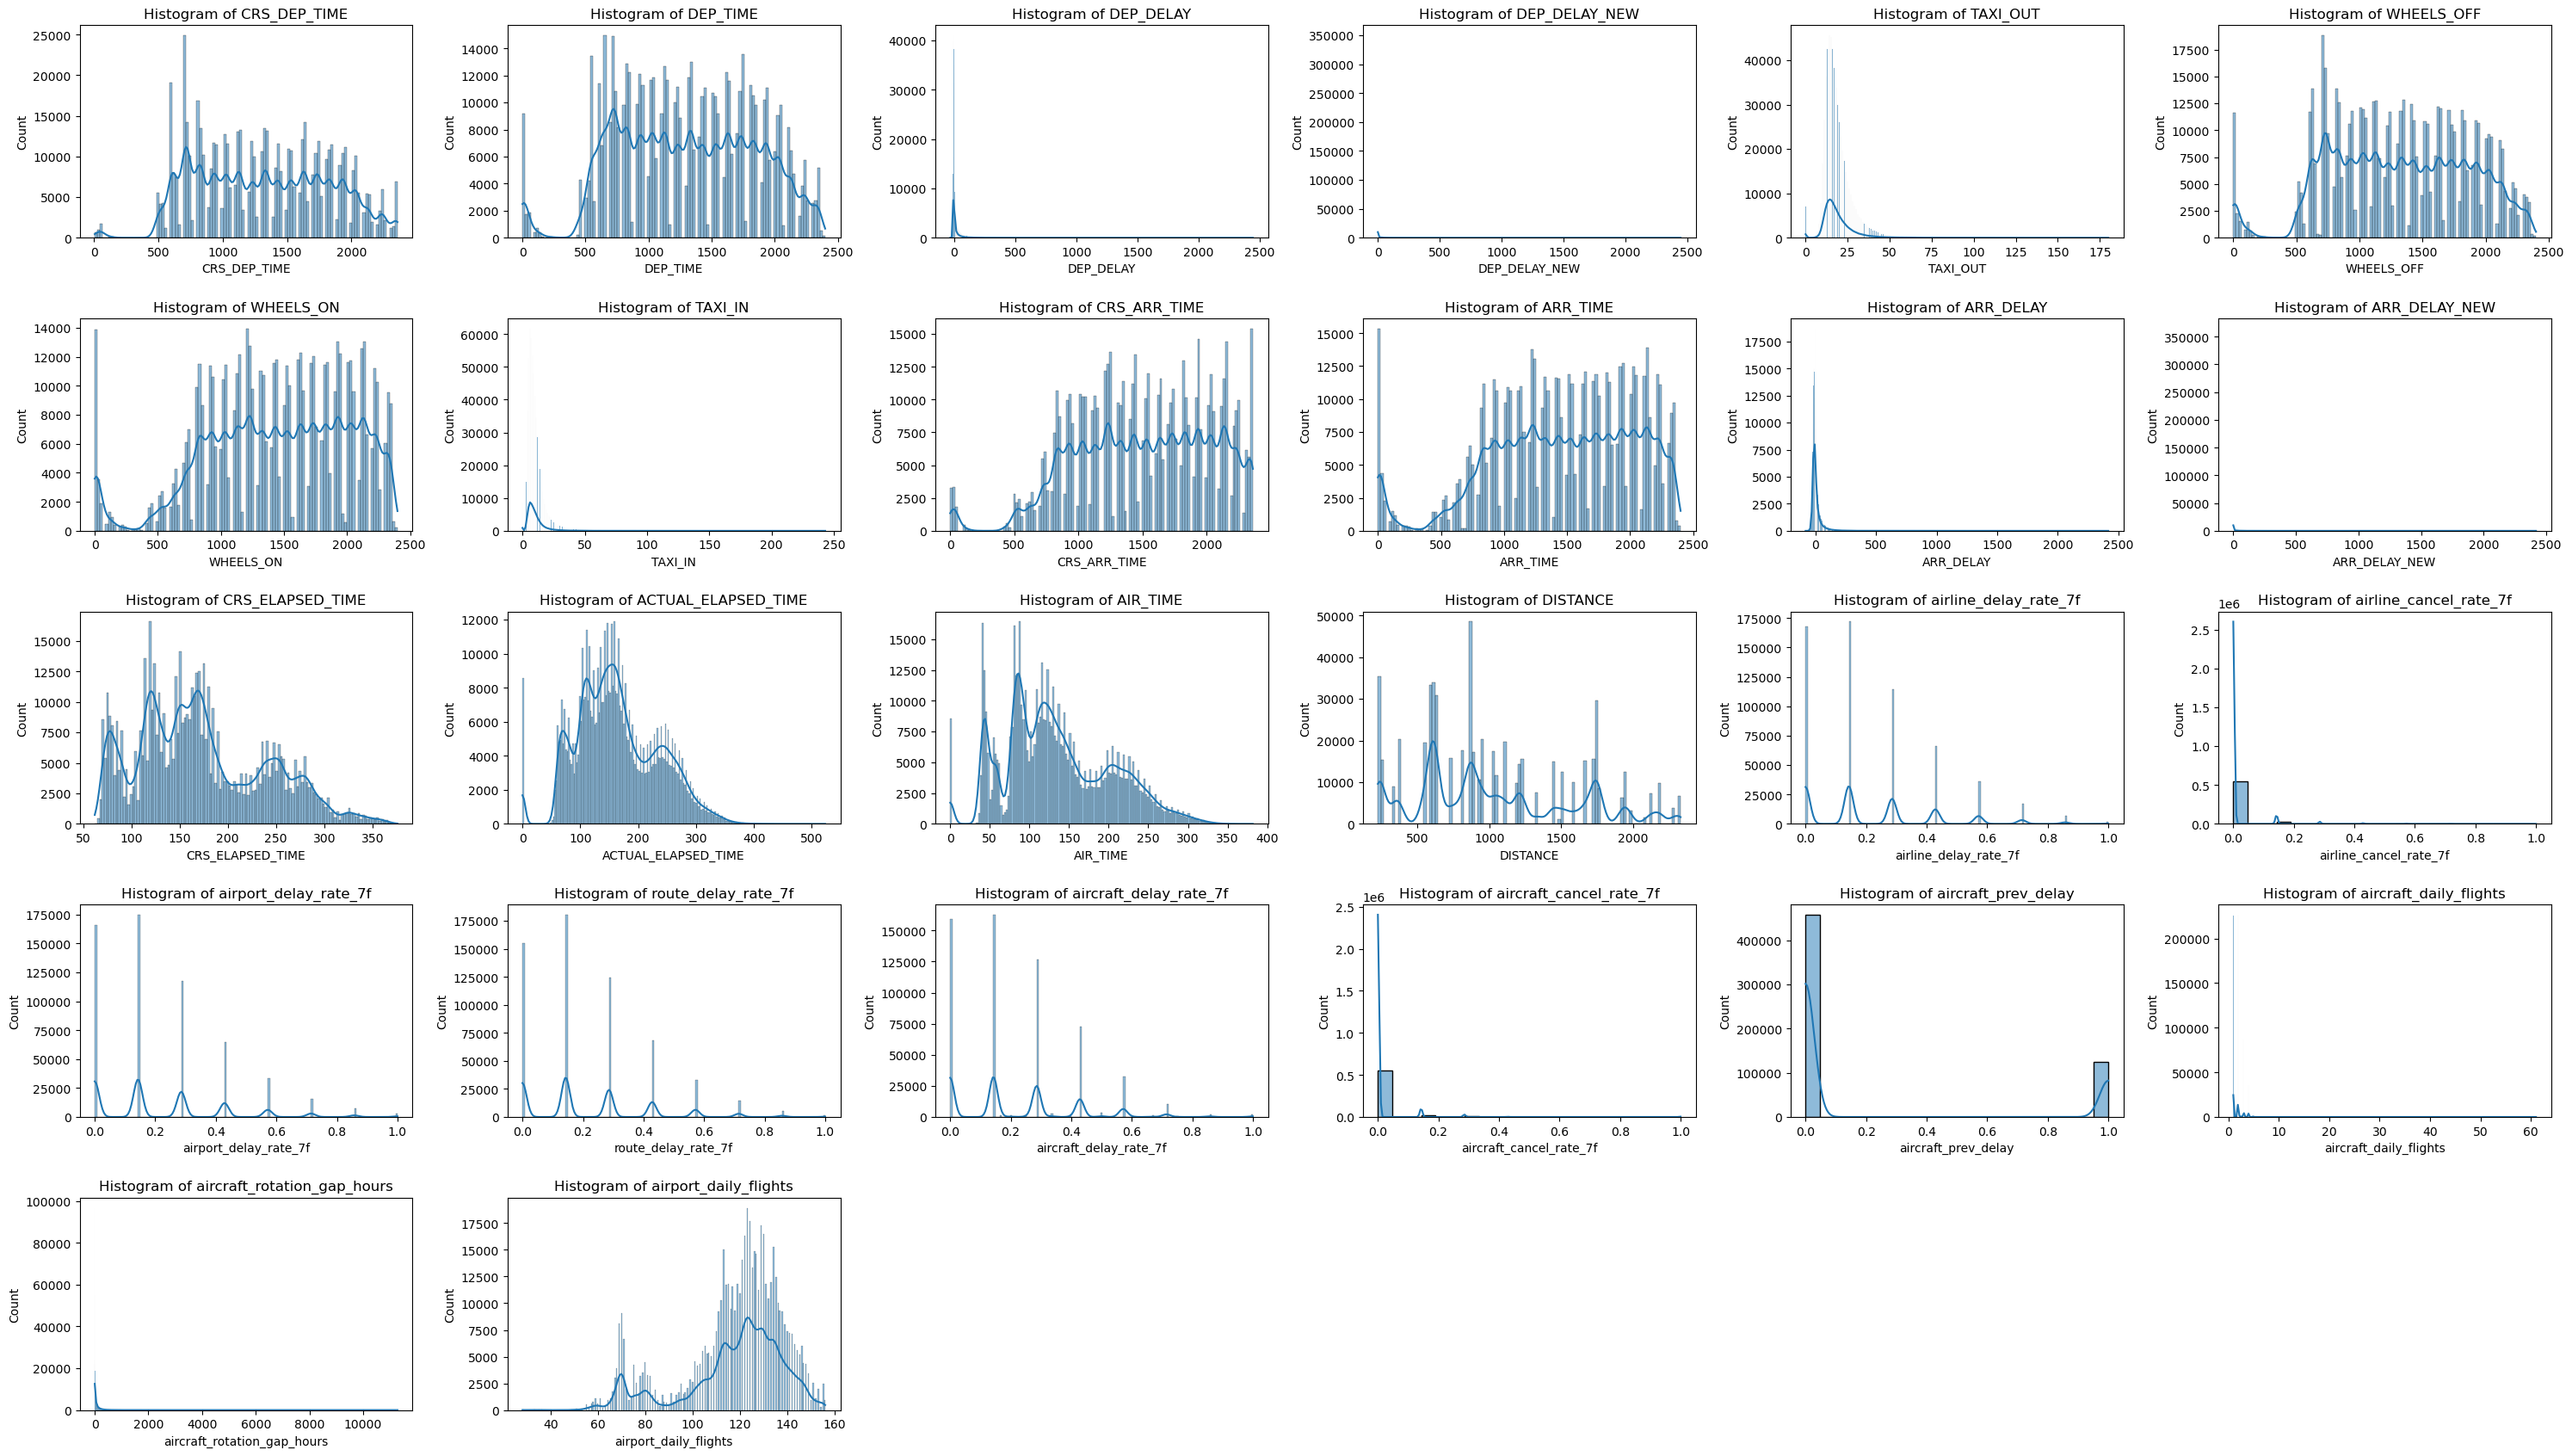

In [52]:
# ============================================================
# UNIVARIATE ANALYSIS — CONTINUOUS NUMERIC
# ============================================================

plt.figure(figsize=(30, 20))
t = 1

for i in continuous_cols:
    plt.subplot(6, 6, t)

    if i in zero_inflated_cols:
        sns.histplot(df_filtered[df_filtered[i] > 0][i], kde=True)
    else:
        sns.histplot(df_filtered[i], kde=True)

    plt.title(f'Histogram of {i}')
    t += 1

plt.tight_layout()
plt.show()

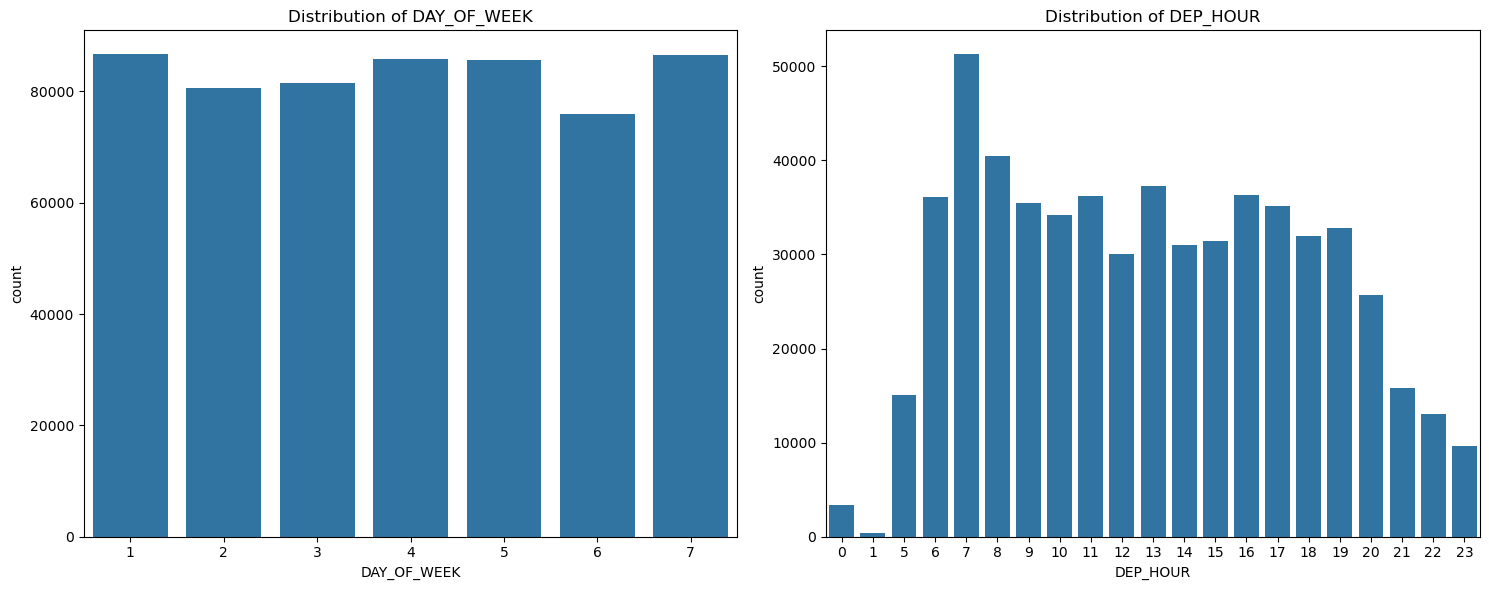

In [53]:
# ============================================================
# UNIVARIATE ANALYSIS — DISCRETE NUMERIC
# ============================================================

plt.figure(figsize=(15, 6))
t = 1

for i in discrete_cols:
    plt.subplot(1, len(discrete_cols), t)
    sns.countplot(x=df_filtered[i])
    plt.title(f'Distribution of {i}')
    t += 1

plt.tight_layout()
plt.show()

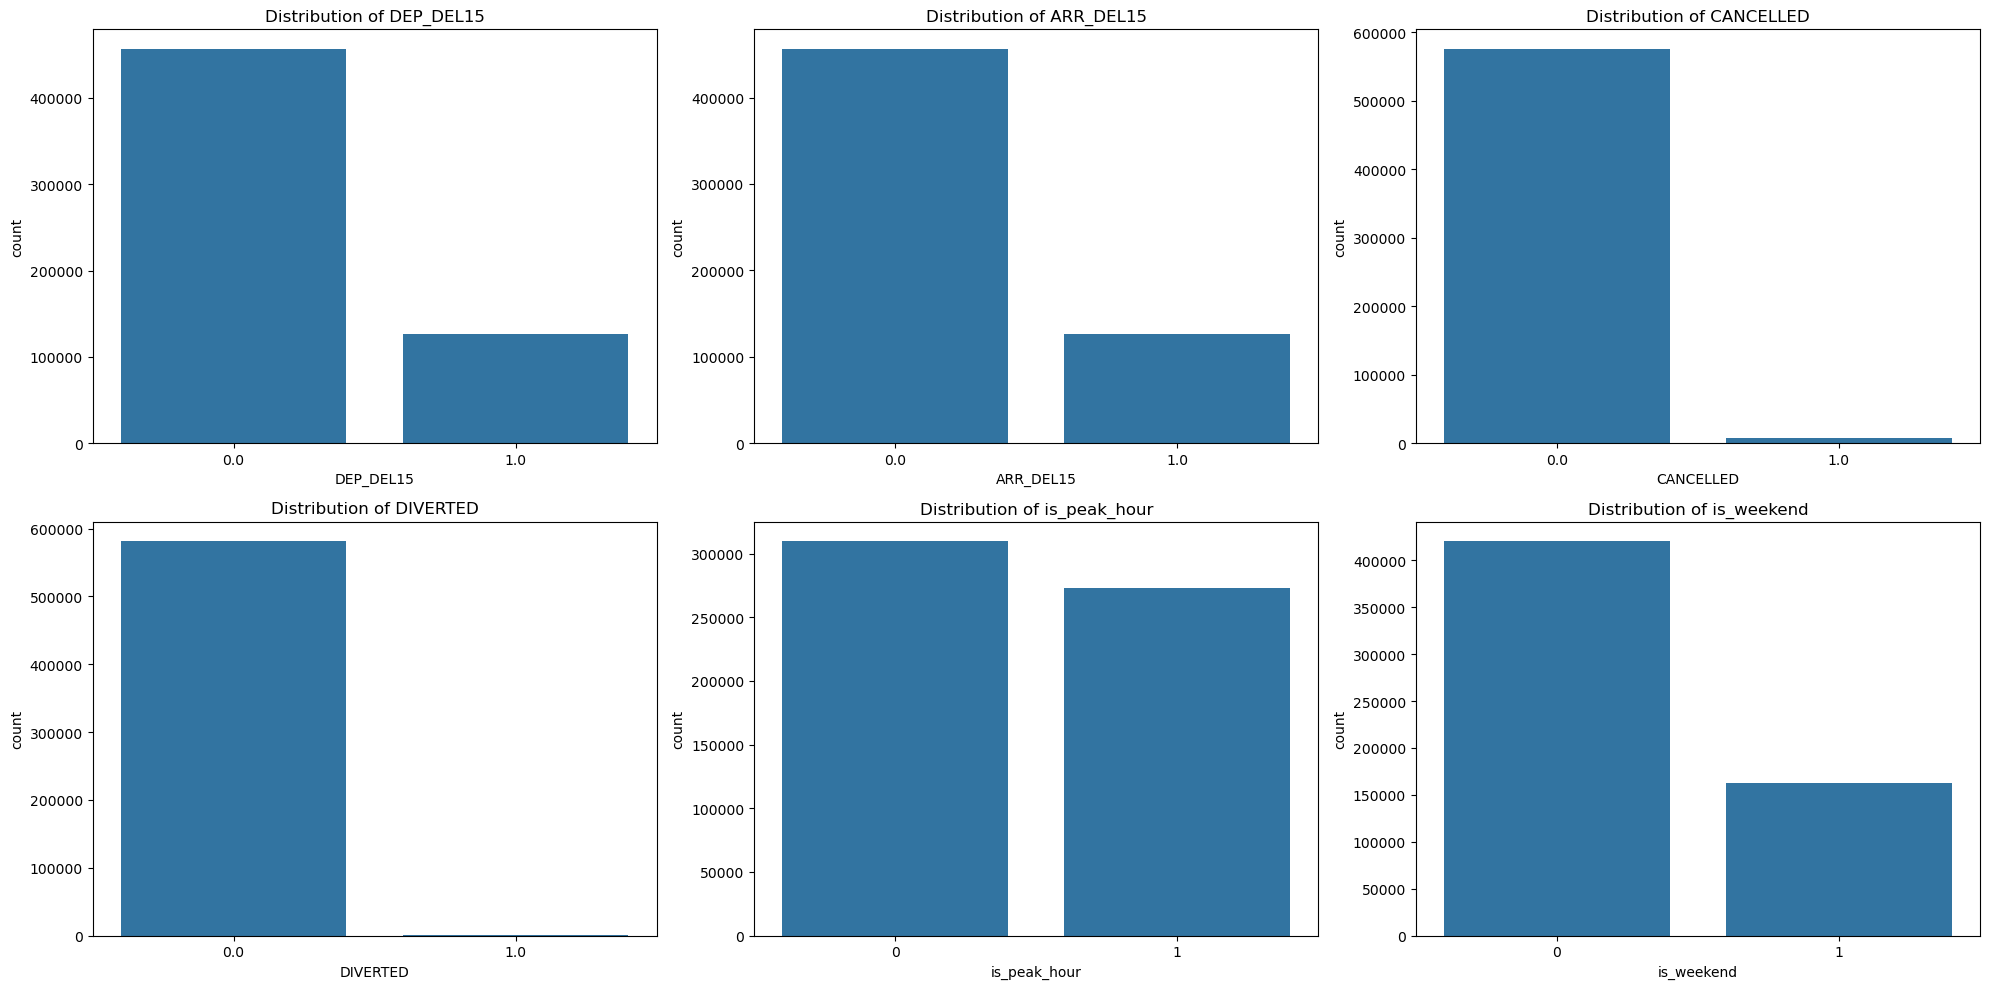

In [54]:
# ============================================================
# UNIVARIATE ANALYSIS — BINARY NUMERIC
# ============================================================

plt.figure(figsize=(20, 10))
t = 1

for i in binary_cols:
    plt.subplot(2, 3, t)
    sns.countplot(x=df_filtered[i])
    plt.title(f'Distribution of {i}')
    t += 1

plt.tight_layout()
plt.show()

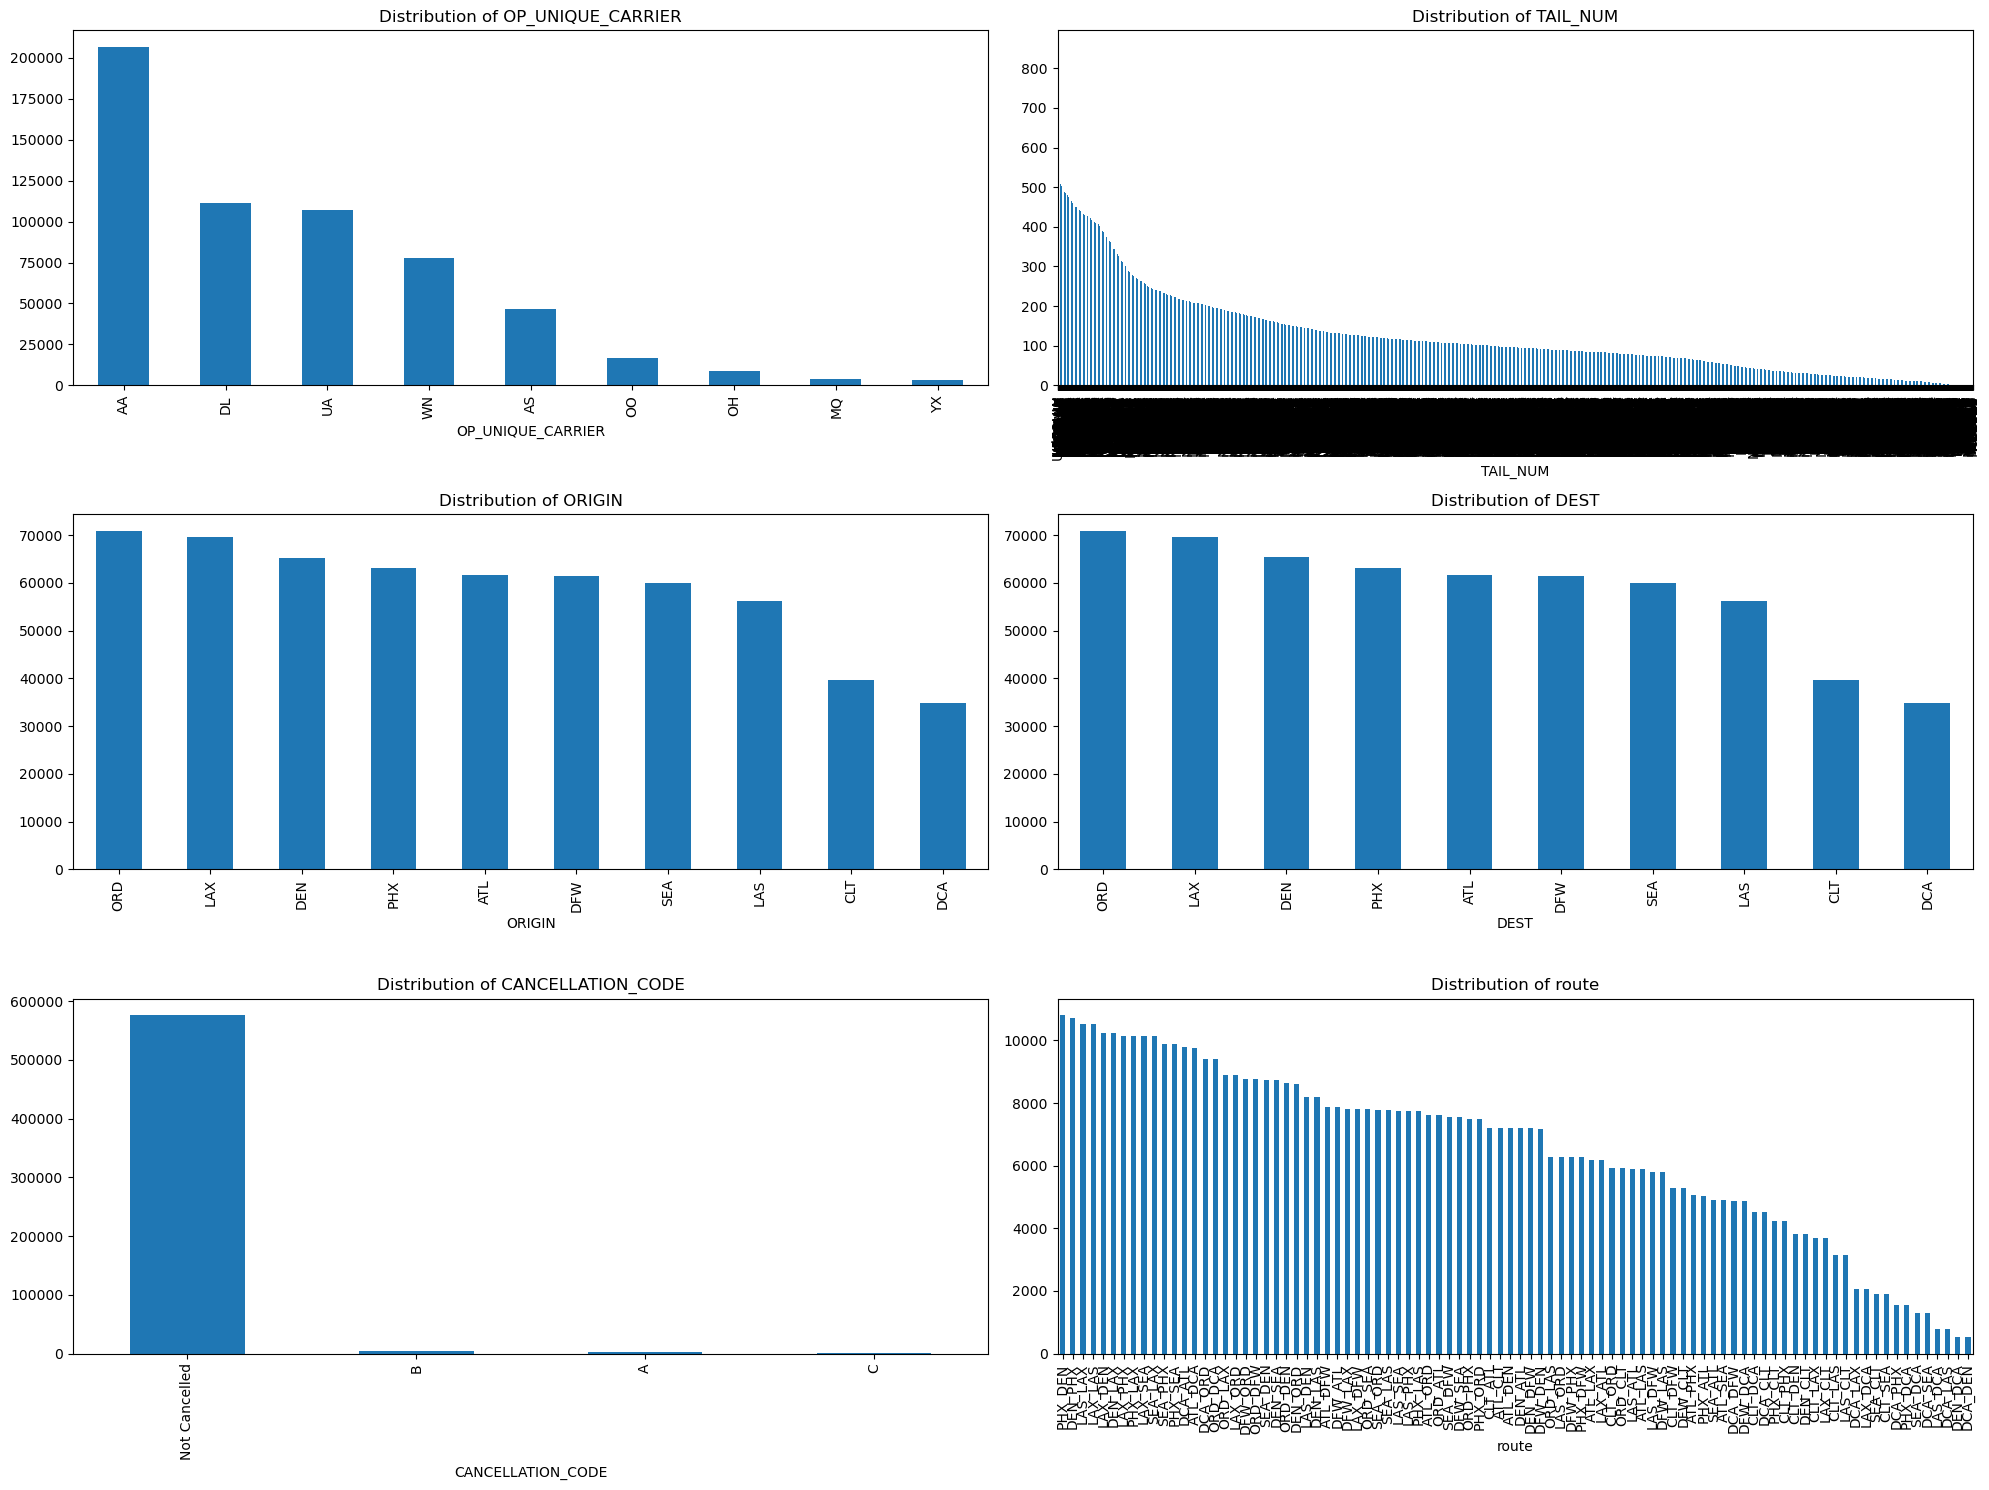

In [55]:
# ============================================================
# UNIVARIATE ANALYSIS — CATEGORICAL COLUMNS
# ============================================================

plt.figure(figsize=(20, 15))
t = 1

for i in cat_cols:
    plt.subplot(3, 2, t)
    df_filtered[i].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {i}')
    t += 1

plt.tight_layout()
plt.show()

### Bivariate Plots

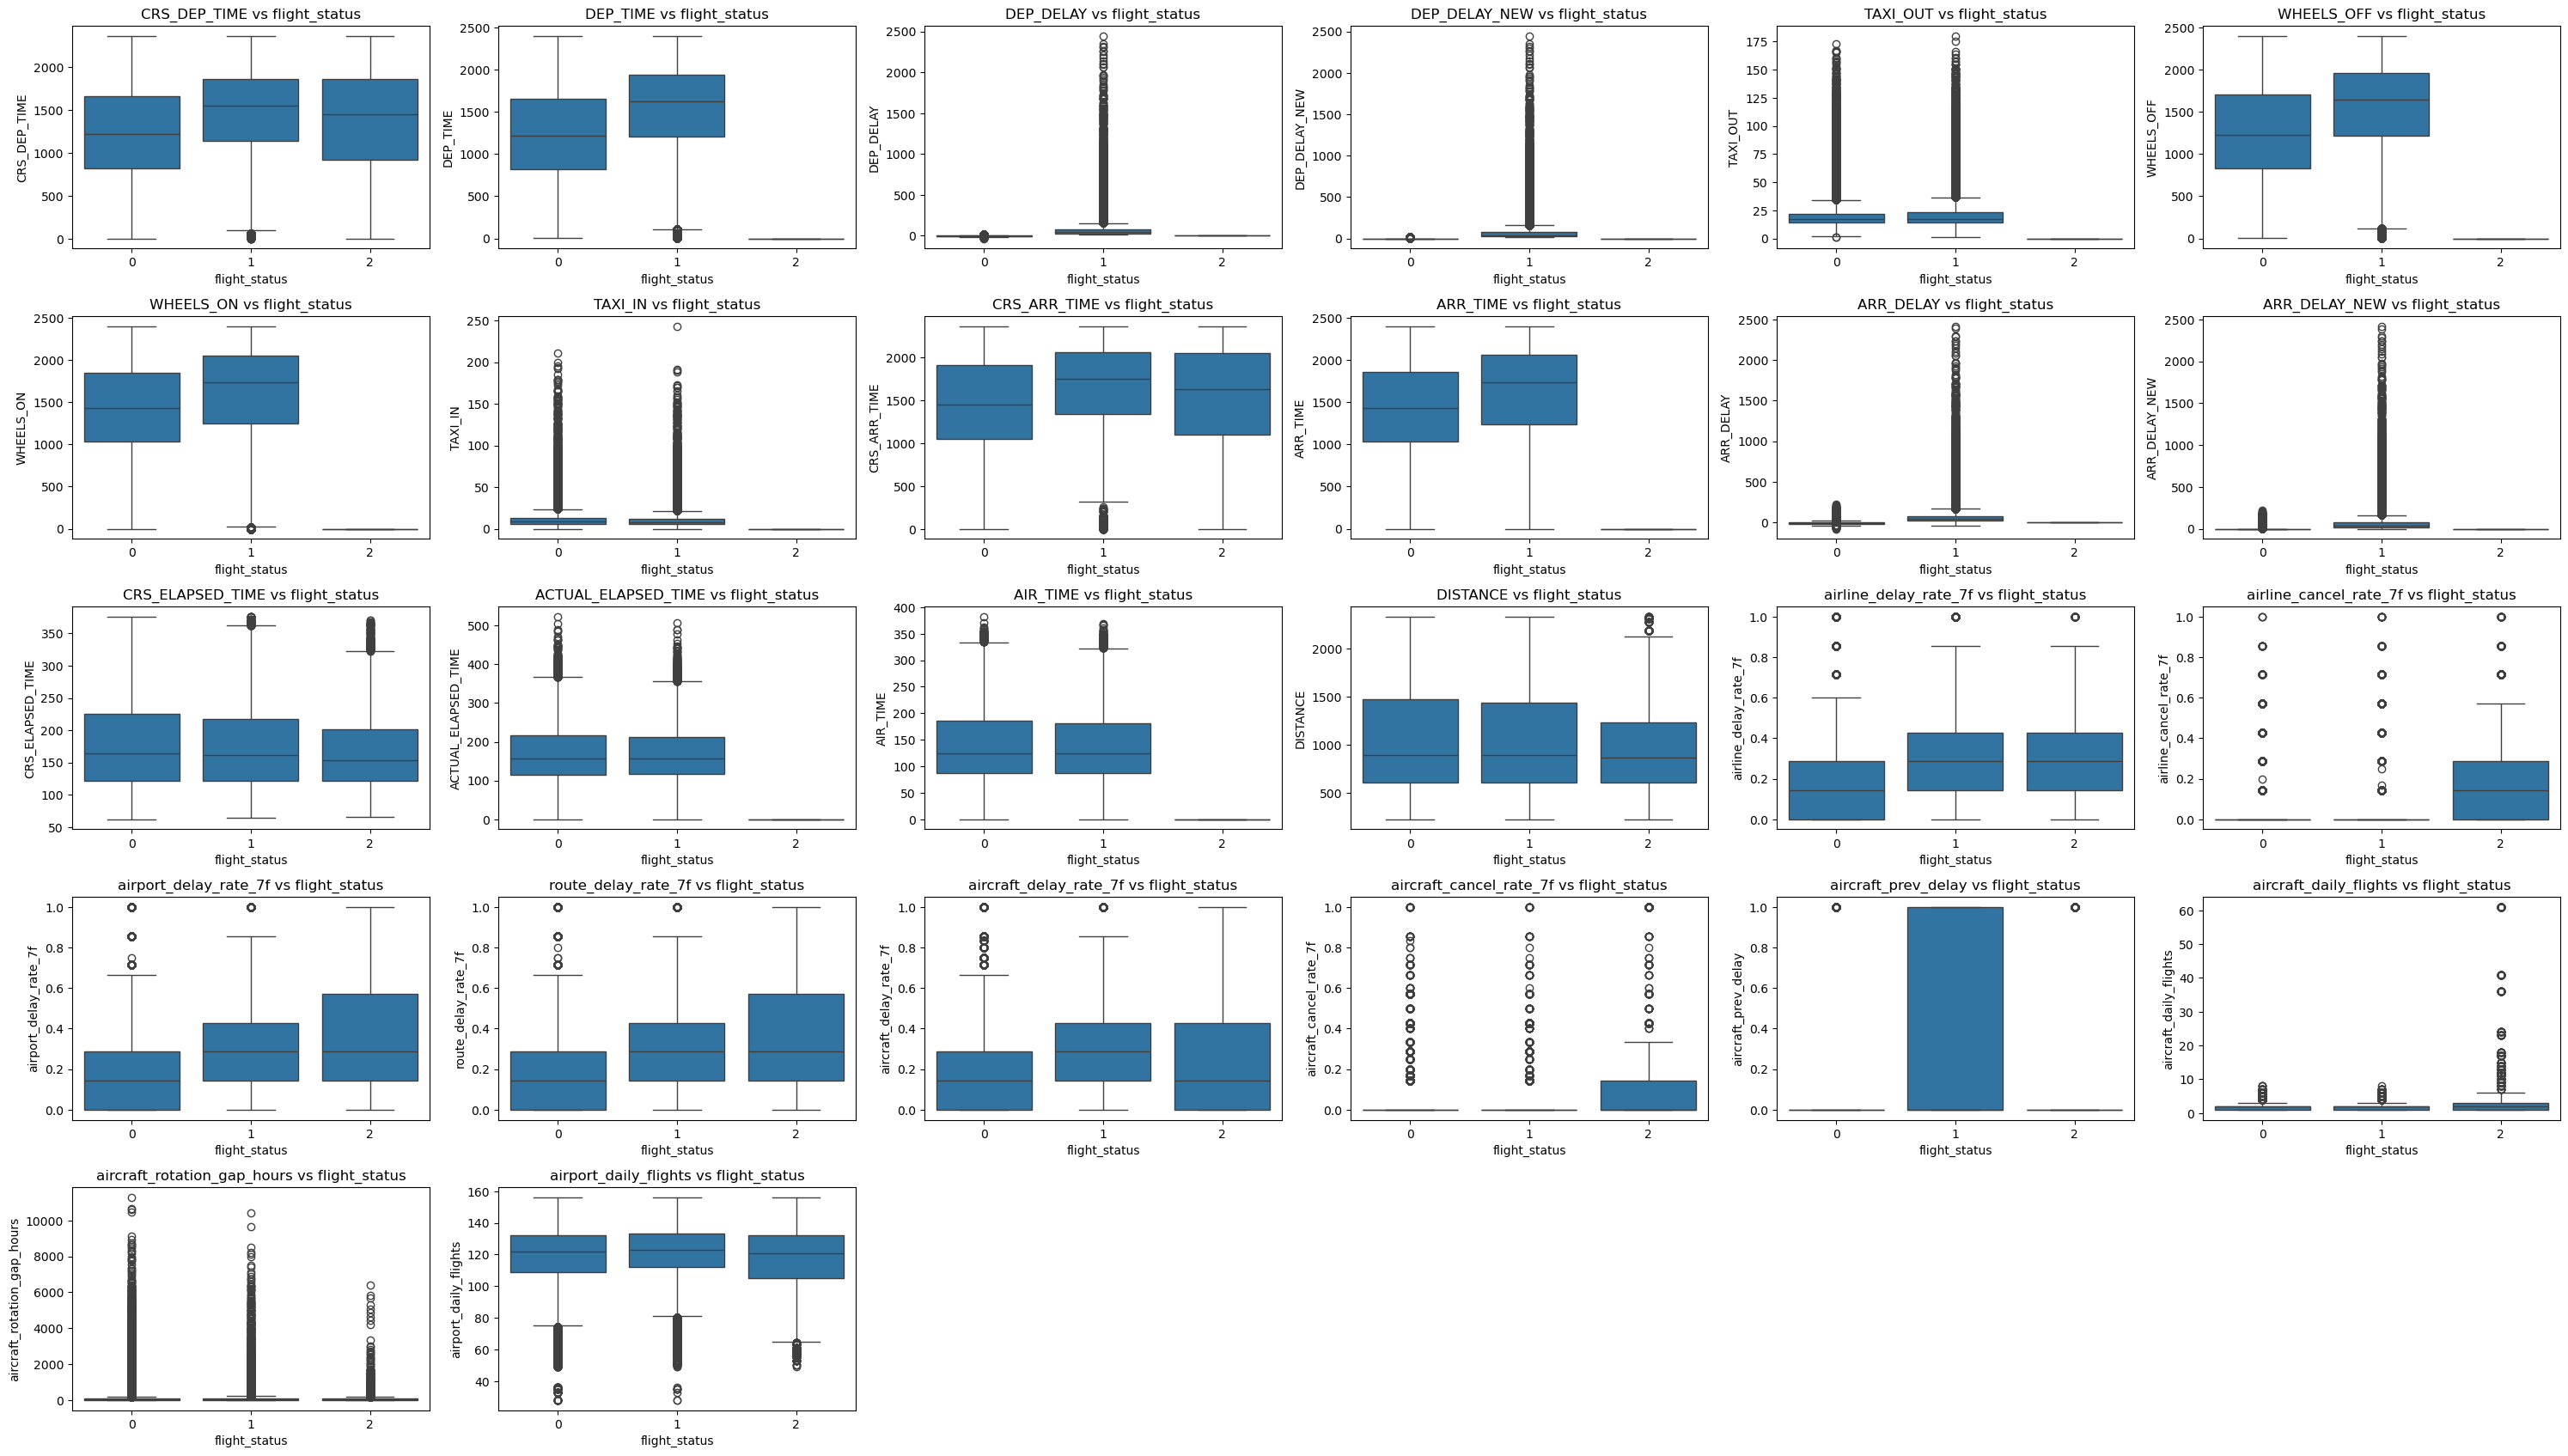

In [57]:
# ============================================================
# BIVARIATE ANALYSIS — CONTINUOS NUMERIC VS TARGET
# ============================================================
plt.figure(figsize=(30, 20))
t = 1

for i in continuous_cols:
    plt.subplot(6, 6, t)

    if i in zero_inflated_cols:
        sns.boxplot(
            x='flight_status',
            y=i,
            data=df_filtered[df_filtered[i] > 0]
        )
    else:
        sns.boxplot(
            x='flight_status',
            y=i,
            data=df_filtered
        )

    plt.title(f'{i} vs flight_status')
    t += 1

plt.tight_layout()
plt.show()

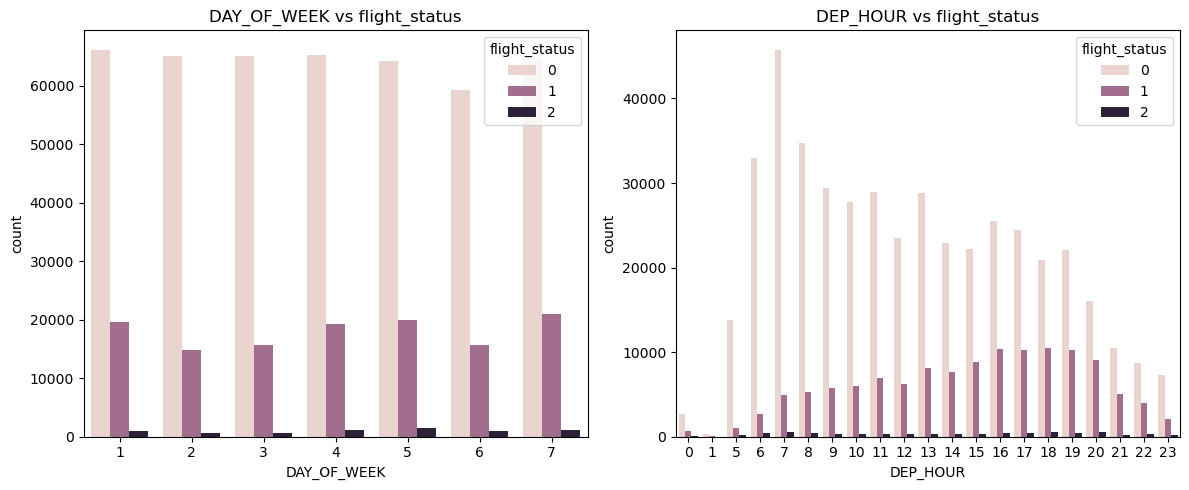

In [58]:
# ============================================================
# BIVARIATE ANALYSIS — DISCRETE NUMERIC VS TARGET
# ============================================================
plt.figure(figsize=(12, 5))
t = 1

for i in discrete_cols:
    plt.subplot(1, 2, t)
    sns.countplot(x=i, hue='flight_status', data=df_filtered)
    plt.title(f'{i} vs flight_status')
    t += 1

plt.tight_layout()
plt.show()

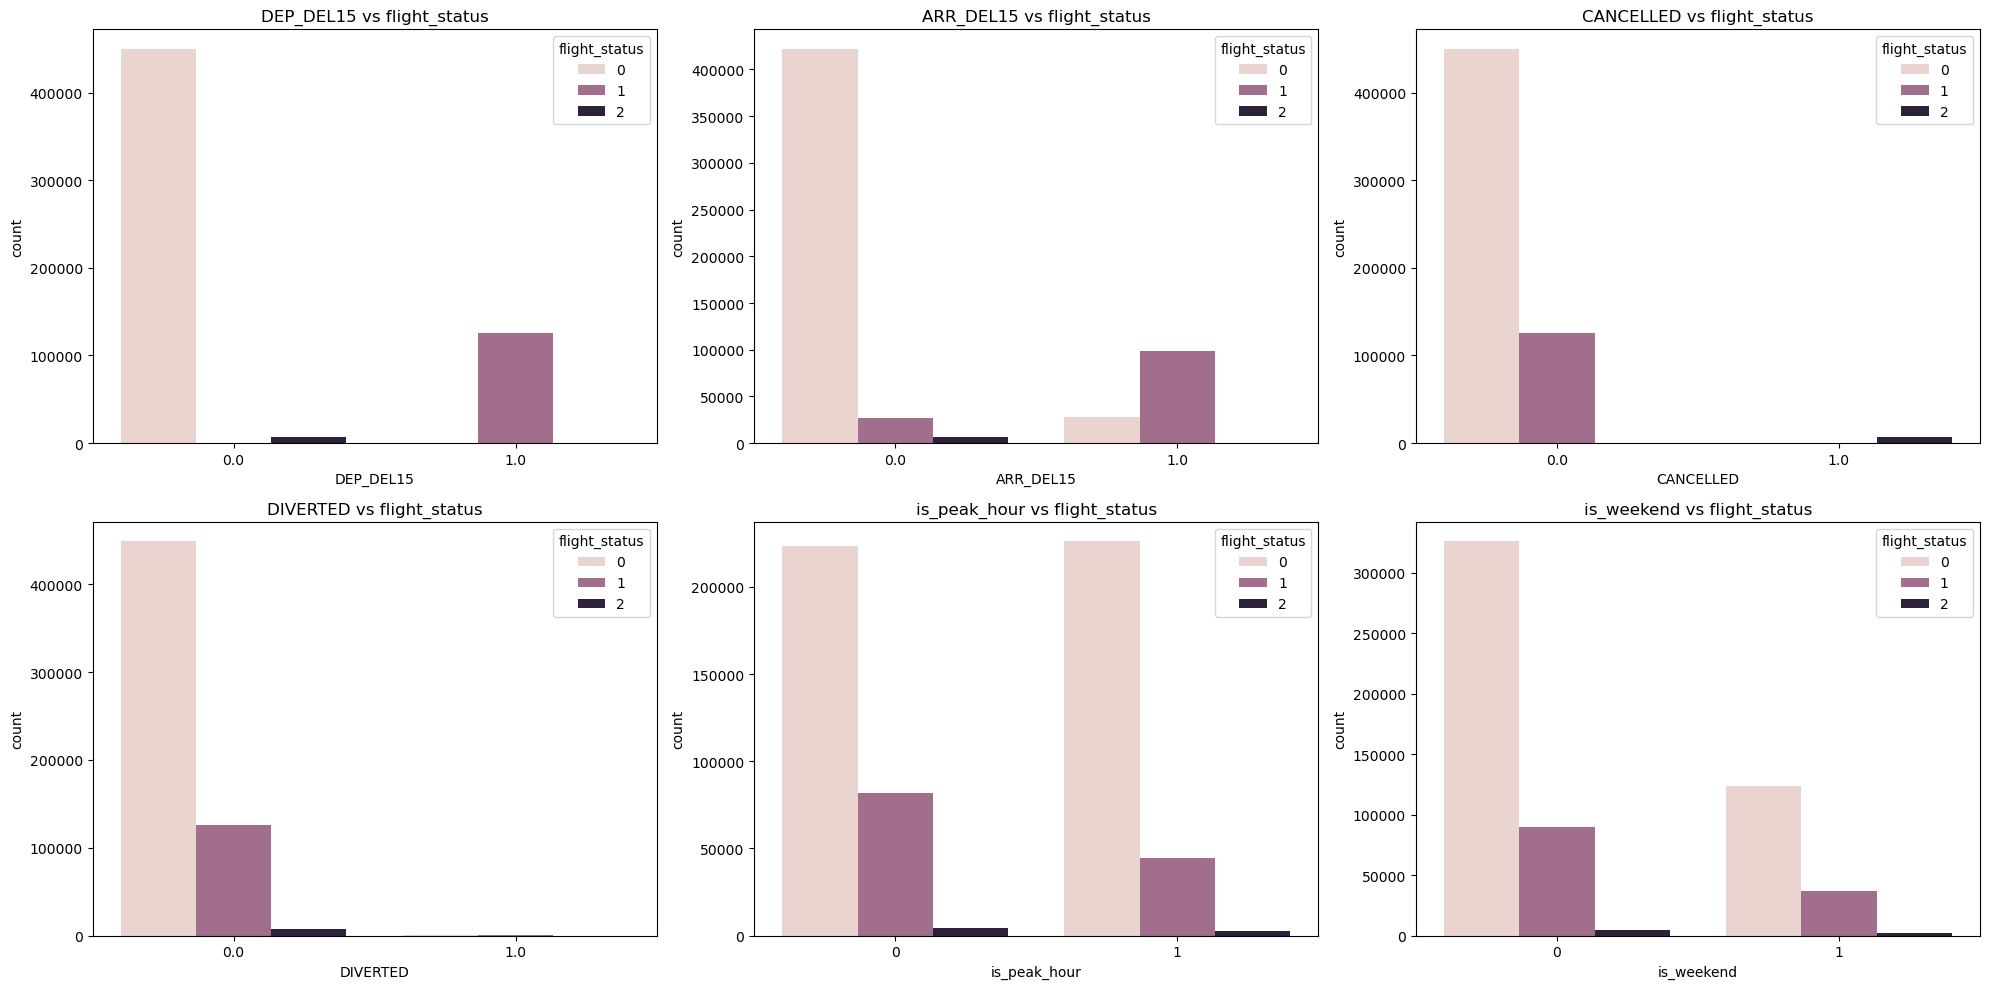

In [59]:
# ============================================================
# BIVARIATE ANALYSIS — BINARY VS TARGET
# ============================================================
plt.figure(figsize=(20, 10))
t = 1

for i in binary_cols:
    plt.subplot(2, 3, t)
    sns.countplot(x=i, hue='flight_status', data=df_filtered)
    plt.title(f'{i} vs flight_status')
    t += 1

plt.tight_layout()
plt.show()

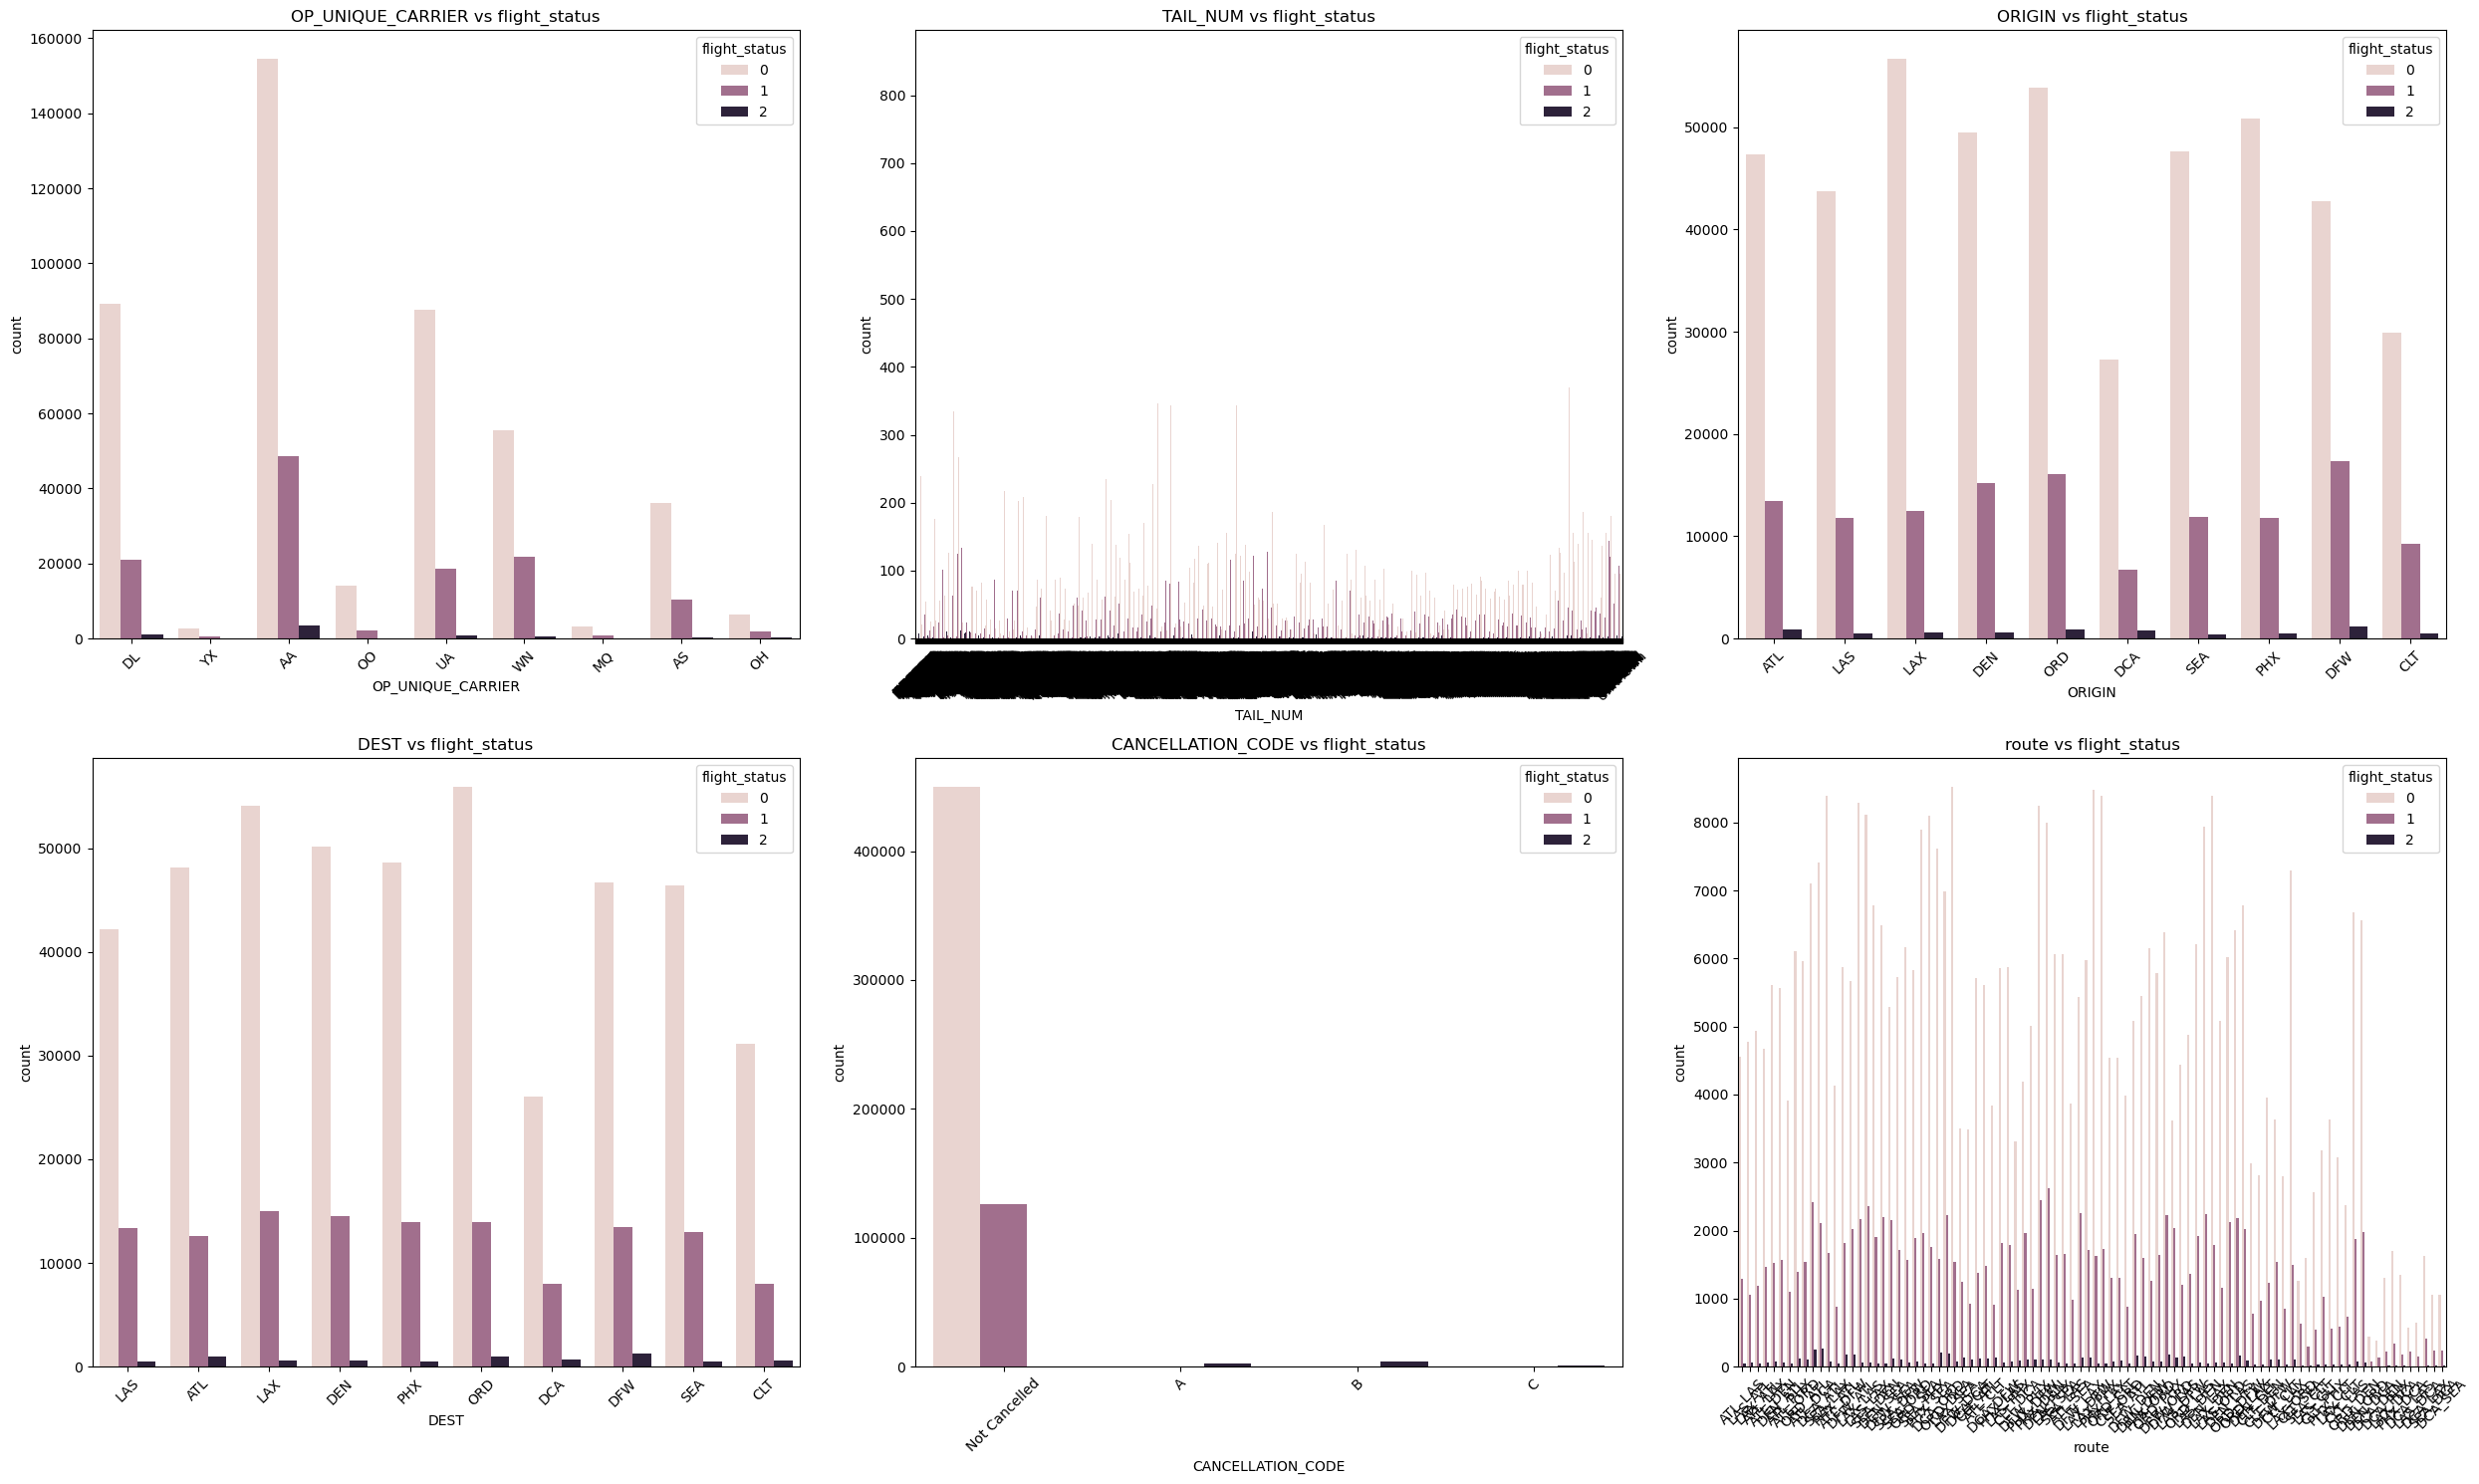

In [60]:
# ============================================================
# BIVARIATE ANALYSIS — CATEGORICAL VS TARGET
# ============================================================
plt.figure(figsize=(25, 15))
t = 1

for i in cat_cols:
    plt.subplot(2, 3, t)
    sns.countplot(x=i, hue='flight_status', data=df_filtered)
    plt.xticks(rotation=45)
    plt.title(f'{i} vs flight_status')
    t += 1

plt.tight_layout()
plt.show()

### Multivariate Plots

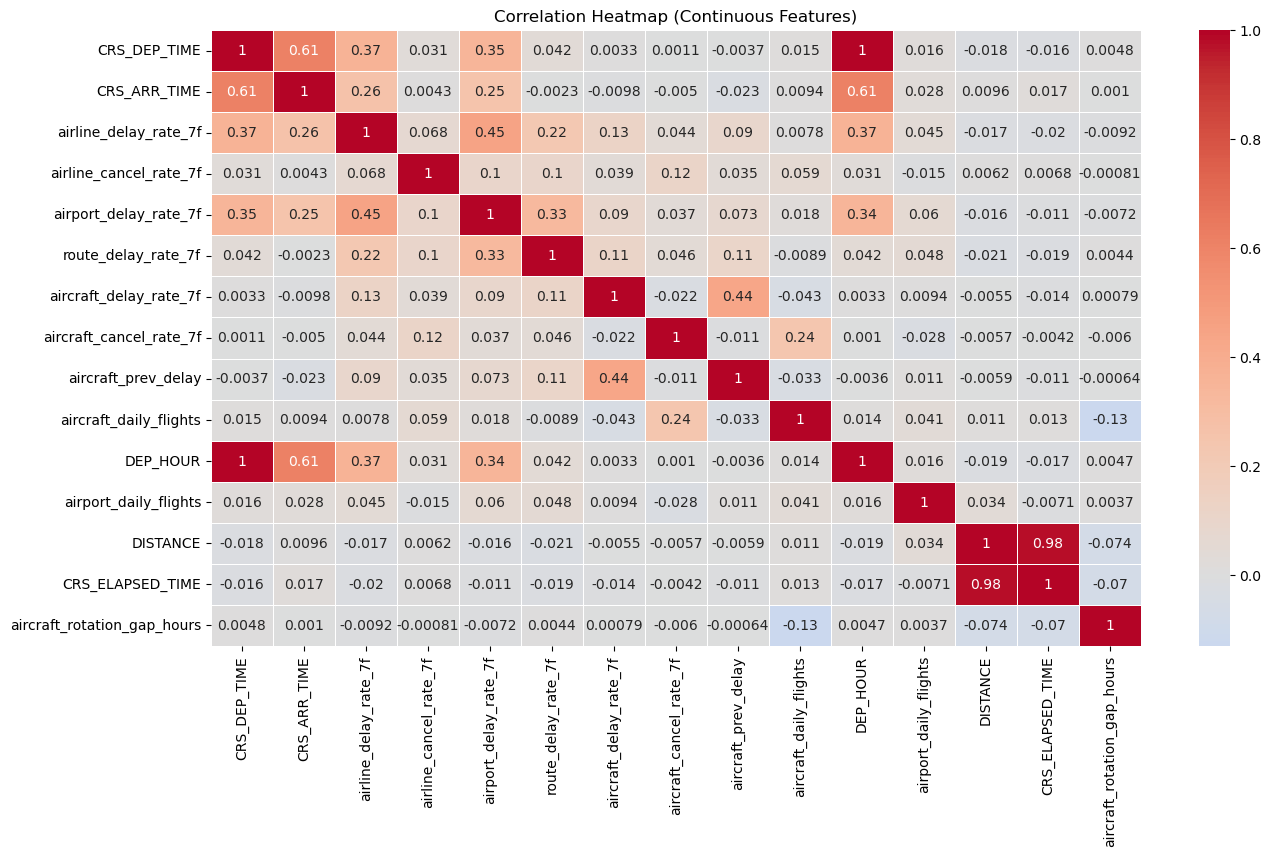

In [202]:
# ====================================================================
# MULTIVARIATE ANALYSIS — CORRELATION HEATMAP USING CONTINUOS COLUMNS
# ====================================================================
plt.figure(figsize=(15, 8))

corr_matrix = df_filtered[continuous_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot = True
)

plt.title("Correlation Heatmap (Continuous Features)")
plt.show()

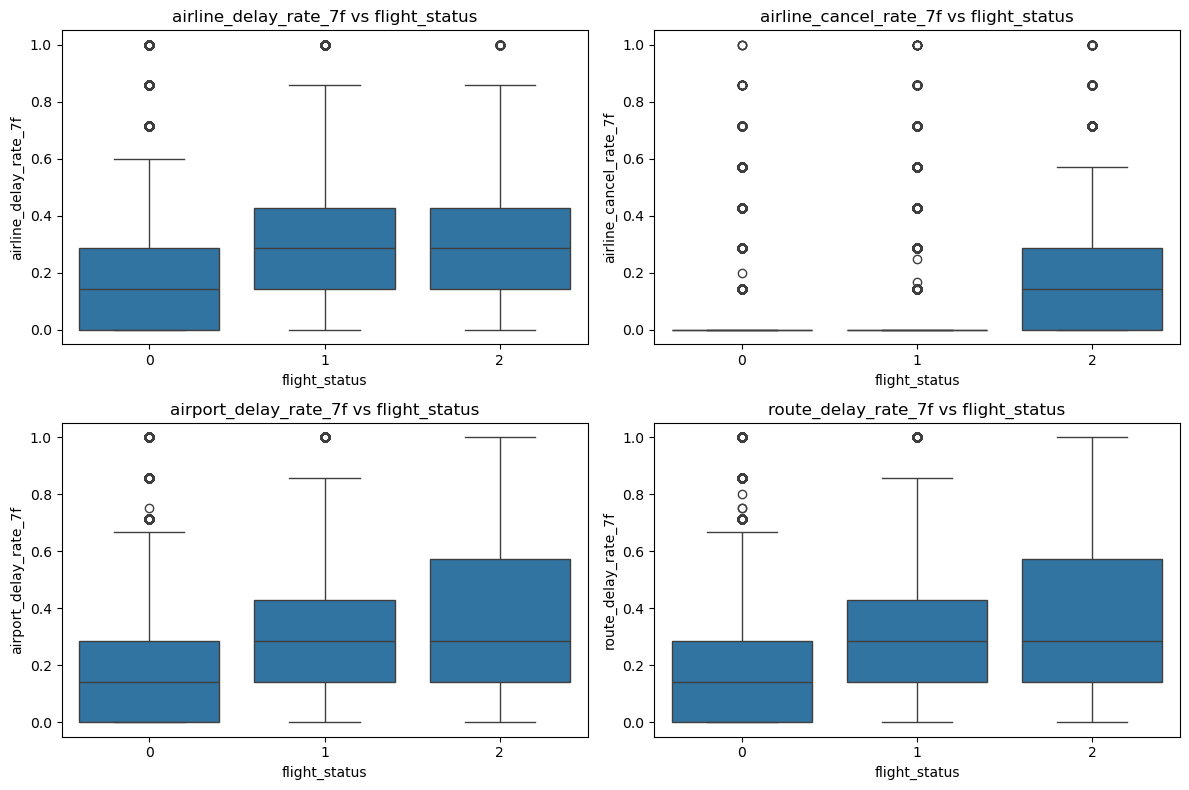

In [63]:
# ====================================================================
# MULTIVARIATE ANALYSIS — ROLLING FEATURES VS TARGET
# ====================================================================
rolling_features = [
    'airline_delay_rate_7f',
    'airline_cancel_rate_7f',
    'airport_delay_rate_7f',
    'route_delay_rate_7f'
]

plt.figure(figsize=(12,8))

for i, col in enumerate(rolling_features, 1):
    plt.subplot(2,2,i)
    sns.boxplot(x='flight_status', y=col, data=df_filtered)
    plt.title(f'{col} vs flight_status')

plt.tight_layout()
plt.show()

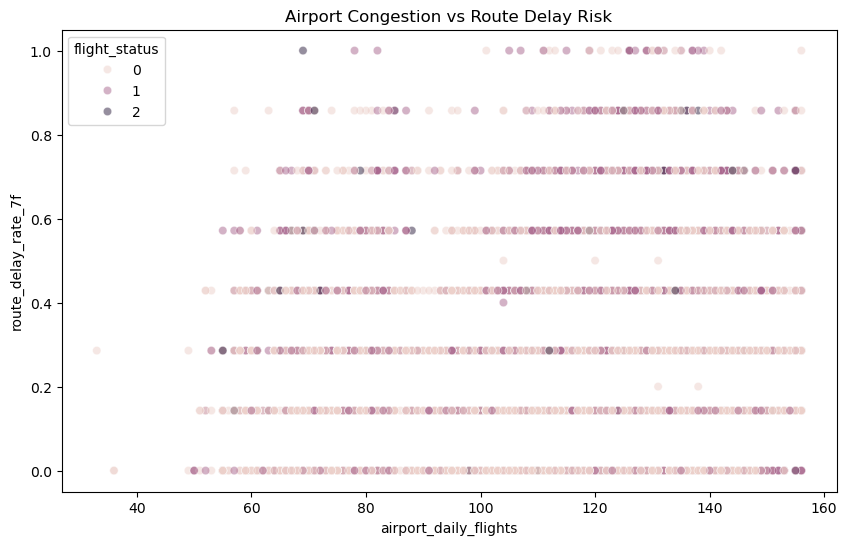

In [64]:
# ============================================================
# MULTIVARIATE 3 — Congestion vs Route Delay
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='airport_daily_flights',
    y='route_delay_rate_7f',
    hue='flight_status',
    alpha=0.5,
    data=df_filtered.sample(20000)  # sample for clarity
)

plt.title("Airport Congestion vs Route Delay Risk")
plt.show()

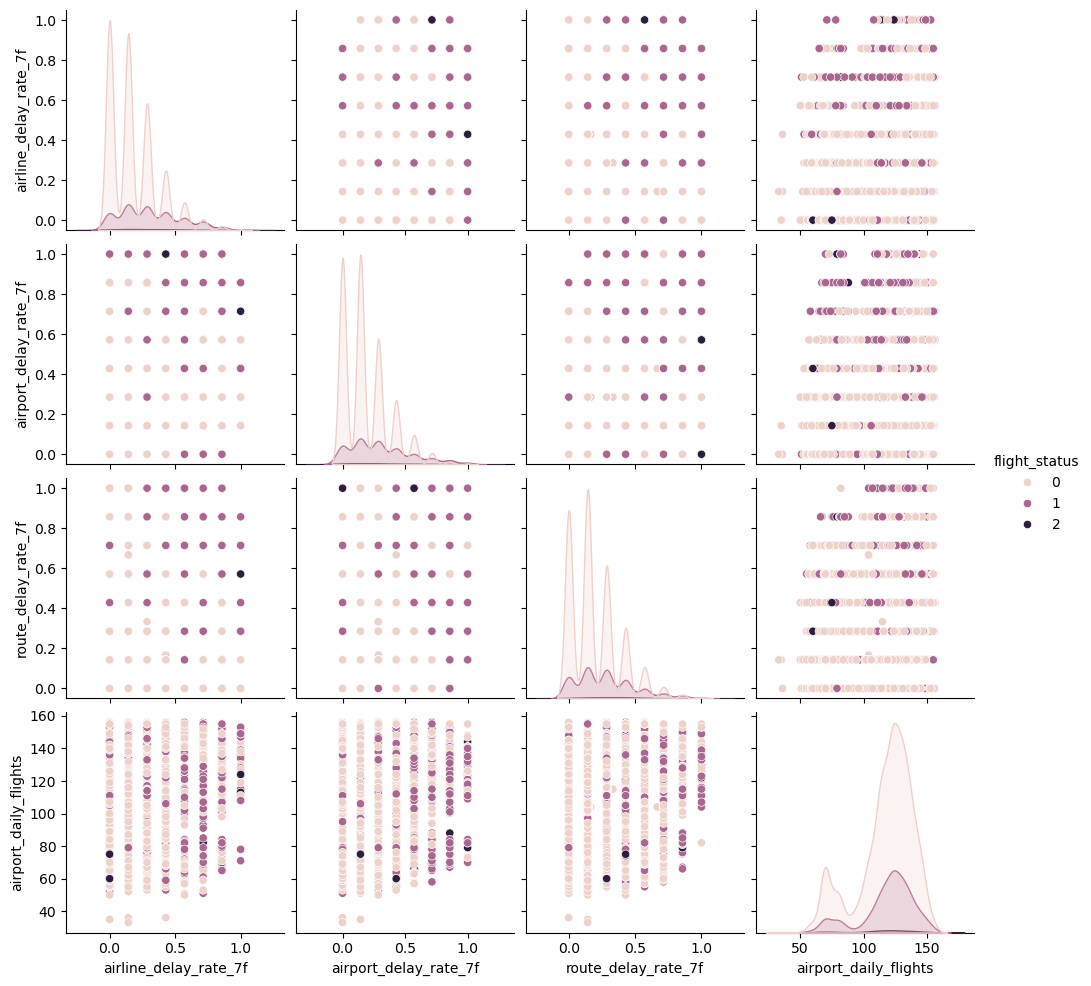

In [65]:
# ============================================================
# MULTIVARIATE 4 — Engineered Risk Pairplot
# ============================================================

risk_cols = [
    'airline_delay_rate_7f',
    'airport_delay_rate_7f',
    'route_delay_rate_7f',
    'airport_daily_flights'
]

sns.pairplot(
    df_filtered[risk_cols + ['flight_status']].sample(15000),
    hue='flight_status',
    diag_kind='kde'
)

plt.show()

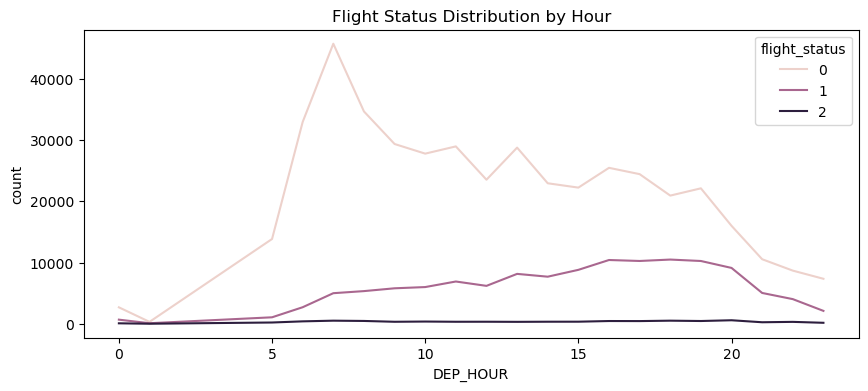

In [196]:
# ============================================================
# MULTIVARIATE 5 — Peak Hour Effect
# ============================================================

peak_effect = (
    df_filtered
    .groupby(['DEP_HOUR', 'flight_status'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(10,4))

sns.lineplot(
    x='DEP_HOUR',
    y='count',
    hue='flight_status',
    data=peak_effect
)

plt.title("Flight Status Distribution by Hour")
plt.show()

In [67]:
# Create modeling copy
df_model = df_filtered.copy()

print("Initial shape:", df_model.shape)

Initial shape: (582632, 50)


In [68]:
# ============================================================
# DROP LEAKAGE + ID COLUMNS
# ============================================================

leakage_cols = [
    # Direct target components
    'DEP_DEL15',
    'CANCELLED',

    # Post-departure actuals
    'DEP_TIME',
    'DEP_DELAY',
    'DEP_DELAY_NEW',
    'ARR_TIME',
    'ARR_DELAY',
    'ARR_DELAY_NEW',
    'ARR_DEL15',
    'DIVERTED',
    'WHEELS_OFF',
    'WHEELS_ON',
    'TAXI_OUT',
    'TAXI_IN',
    'ACTUAL_ELAPSED_TIME',
    'AIR_TIME',

    # Delay causes (post-event)
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY',

    # Cancellation reason
    'CANCELLATION_CODE'
]

id_cols_to_drop = [
    'OP_CARRIER_FL_NUM',
    'ORIGIN_AIRPORT_ID',
    'DEST_AIRPORT_ID'
]

# Drop safely
df_model = df_filtered.copy()

df_model.drop(
    columns=leakage_cols + id_cols_to_drop,
    inplace=True,
    errors='ignore'
)

print("Final Shape After Dropping:", df_model.shape)
print("\nRemaining Columns:")
print(df_model.columns.tolist())

Final Shape After Dropping: (582632, 25)

Remaining Columns:
['DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'flight_status', 'airline_delay_rate_7f', 'airline_cancel_rate_7f', 'airport_delay_rate_7f', 'route', 'route_delay_rate_7f', 'aircraft_delay_rate_7f', 'aircraft_cancel_rate_7f', 'aircraft_prev_delay', 'aircraft_daily_flights', 'aircraft_rotation_gap_hours', 'airport_daily_flights', 'DEP_HOUR', 'is_peak_hour', 'is_weekend']


In [69]:
from sklearn.preprocessing import LabelEncoder

# ============================================================
#  Frequency Encoding (High Cardinality)
# ============================================================
# Route would explode with OneHot → so we use frequency encoding

route_freq = df_model['route'].value_counts(normalize=True)

df_model['route_freq'] = df_model['route'].map(route_freq)

# Drop original route column
df_model.drop(columns=['route'], inplace=True)


# ============================================================
#  Label Encoding (High Cardinality Safe for Trees)
# ============================================================

le_tail = LabelEncoder()
df_model['TAIL_NUM'] = le_tail.fit_transform(df_model['TAIL_NUM'])


# ============================================================
#  One-Hot Encoding (Low Cardinality)
# ============================================================

one_hot_cols = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST']

df_model = pd.get_dummies(
    df_model,
    columns=one_hot_cols,
    drop_first=True  # avoid dummy trap for logistic regression
)

print("Shape after encoding:", df_model.shape)
print("Remaining columns:", len(df_model.columns))

Shape after encoding: (582632, 48)
Remaining columns: 48


In [270]:
import joblib

# Save Label Encoder
joblib.dump(le_tail, "le_tail.pkl")

# Save Frequency Mapping
joblib.dump(route_freq, "route_frequency.pkl")

print("Encoders saved successfully.")

Encoders saved successfully.


In [71]:
# ------------------------------------------------------------
# 1️⃣ Ensure chronological order
# ------------------------------------------------------------
df_model = df_model.sort_values('FL_DATE')


# ------------------------------------------------------------
# 2️⃣ Define split date
# ------------------------------------------------------------
split_date = pd.Timestamp('2025-10-01')


# ------------------------------------------------------------
# 3️⃣ Create Train & Test
# ------------------------------------------------------------
train = df_model[df_model['FL_DATE'] < split_date].copy()
test  = df_model[df_model['FL_DATE'] >= split_date].copy()


# ------------------------------------------------------------
# 4️⃣ Separate Features & Target
# ------------------------------------------------------------
target_col = 'flight_status'

X_train = train.drop(columns=[target_col, 'FL_DATE'])
y_train = train[target_col]

X_test = test.drop(columns=[target_col, 'FL_DATE'])
y_test = test[target_col]


# ------------------------------------------------------------
# 5️⃣ Sanity Check
# ------------------------------------------------------------
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain date range:",
      train['FL_DATE'].min(), "to", train['FL_DATE'].max())

print("Test date range:",
      test['FL_DATE'].min(), "to", test['FL_DATE'].max())

print("\nTarget Distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nTarget Distribution (Test):")
print(y_test.value_counts(normalize=True))

Train shape: (515228, 46)
Test shape: (67404, 46)

Train date range: 2024-07-01 00:00:00 to 2025-09-30 00:00:00
Test date range: 2025-10-01 00:00:00 to 2025-11-30 00:00:00

Target Distribution (Train):
flight_status
0    0.770628
1    0.217729
2    0.011643
Name: proportion, dtype: float64

Target Distribution (Test):
flight_status
0    0.779405
1    0.205670
2    0.014925
Name: proportion, dtype: float64


In [72]:
X_train.columns

Index(['DAY_OF_WEEK', 'TAIL_NUM', 'CRS_DEP_TIME', 'CRS_ARR_TIME',
       'CRS_ELAPSED_TIME', 'DISTANCE', 'airline_delay_rate_7f',
       'airline_cancel_rate_7f', 'airport_delay_rate_7f',
       'route_delay_rate_7f', 'aircraft_delay_rate_7f',
       'aircraft_cancel_rate_7f', 'aircraft_prev_delay',
       'aircraft_daily_flights', 'aircraft_rotation_gap_hours',
       'airport_daily_flights', 'DEP_HOUR', 'is_peak_hour', 'is_weekend',
       'route_freq', 'OP_UNIQUE_CARRIER_AS', 'OP_UNIQUE_CARRIER_DL',
       'OP_UNIQUE_CARRIER_MQ', 'OP_UNIQUE_CARRIER_OH', 'OP_UNIQUE_CARRIER_OO',
       'OP_UNIQUE_CARRIER_UA', 'OP_UNIQUE_CARRIER_WN', 'OP_UNIQUE_CARRIER_YX',
       'ORIGIN_CLT', 'ORIGIN_DCA', 'ORIGIN_DEN', 'ORIGIN_DFW', 'ORIGIN_LAS',
       'ORIGIN_LAX', 'ORIGIN_ORD', 'ORIGIN_PHX', 'ORIGIN_SEA', 'DEST_CLT',
       'DEST_DCA', 'DEST_DEN', 'DEST_DFW', 'DEST_LAS', 'DEST_LAX', 'DEST_ORD',
       'DEST_PHX', 'DEST_SEA'],
      dtype='object')

In [73]:
X_test.columns

Index(['DAY_OF_WEEK', 'TAIL_NUM', 'CRS_DEP_TIME', 'CRS_ARR_TIME',
       'CRS_ELAPSED_TIME', 'DISTANCE', 'airline_delay_rate_7f',
       'airline_cancel_rate_7f', 'airport_delay_rate_7f',
       'route_delay_rate_7f', 'aircraft_delay_rate_7f',
       'aircraft_cancel_rate_7f', 'aircraft_prev_delay',
       'aircraft_daily_flights', 'aircraft_rotation_gap_hours',
       'airport_daily_flights', 'DEP_HOUR', 'is_peak_hour', 'is_weekend',
       'route_freq', 'OP_UNIQUE_CARRIER_AS', 'OP_UNIQUE_CARRIER_DL',
       'OP_UNIQUE_CARRIER_MQ', 'OP_UNIQUE_CARRIER_OH', 'OP_UNIQUE_CARRIER_OO',
       'OP_UNIQUE_CARRIER_UA', 'OP_UNIQUE_CARRIER_WN', 'OP_UNIQUE_CARRIER_YX',
       'ORIGIN_CLT', 'ORIGIN_DCA', 'ORIGIN_DEN', 'ORIGIN_DFW', 'ORIGIN_LAS',
       'ORIGIN_LAX', 'ORIGIN_ORD', 'ORIGIN_PHX', 'ORIGIN_SEA', 'DEST_CLT',
       'DEST_DCA', 'DEST_DEN', 'DEST_DFW', 'DEST_LAS', 'DEST_LAX', 'DEST_ORD',
       'DEST_PHX', 'DEST_SEA'],
      dtype='object')

In [74]:
# ============================================================
# SCALING (Strictly Continuous Features Only)
# ============================================================

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1️⃣ Binary columns (DO NOT SCALE)
# ------------------------------------------------------------
binary_cols = [
    'is_peak_hour',
    'is_weekend'
]

# ------------------------------------------------------------
# 2️⃣ Discrete calendar integers (DO NOT SCALE)
# ------------------------------------------------------------
discrete_cols = [
    'DAY_OF_WEEK'
]

# ------------------------------------------------------------
# 3️⃣ One-hot encoded columns (DO NOT SCALE)
# ------------------------------------------------------------
dummy_prefixes = [
    'OP_UNIQUE_CARRIER_',
    'ORIGIN_',
    'DEST_'
]

dummy_cols = [
    col for col in X_train.columns
    if any(col.startswith(prefix) for prefix in dummy_prefixes)
]

# ------------------------------------------------------------
# 4️⃣ Final Columns to Scale
# ------------------------------------------------------------
cols_to_exclude = binary_cols + discrete_cols + dummy_cols

cols_to_scale = [
    col for col in X_train.columns
    if col not in cols_to_exclude
]

print("Columns NOT scaled:", len(cols_to_exclude))
print(cols_to_exclude)

print("\nColumns TO scale:", len(cols_to_scale))
print(cols_to_scale)

# ------------------------------------------------------------
# 5️⃣ Apply StandardScaler
# ------------------------------------------------------------
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("\nScaling completed safely.")
print("Total features:", len(X_train.columns))

Columns NOT scaled: 29
['is_peak_hour', 'is_weekend', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER_AS', 'OP_UNIQUE_CARRIER_DL', 'OP_UNIQUE_CARRIER_MQ', 'OP_UNIQUE_CARRIER_OH', 'OP_UNIQUE_CARRIER_OO', 'OP_UNIQUE_CARRIER_UA', 'OP_UNIQUE_CARRIER_WN', 'OP_UNIQUE_CARRIER_YX', 'ORIGIN_CLT', 'ORIGIN_DCA', 'ORIGIN_DEN', 'ORIGIN_DFW', 'ORIGIN_LAS', 'ORIGIN_LAX', 'ORIGIN_ORD', 'ORIGIN_PHX', 'ORIGIN_SEA', 'DEST_CLT', 'DEST_DCA', 'DEST_DEN', 'DEST_DFW', 'DEST_LAS', 'DEST_LAX', 'DEST_ORD', 'DEST_PHX', 'DEST_SEA']

Columns TO scale: 17
['TAIL_NUM', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'airline_delay_rate_7f', 'airline_cancel_rate_7f', 'airport_delay_rate_7f', 'route_delay_rate_7f', 'aircraft_delay_rate_7f', 'aircraft_cancel_rate_7f', 'aircraft_prev_delay', 'aircraft_daily_flights', 'aircraft_rotation_gap_hours', 'airport_daily_flights', 'DEP_HOUR', 'route_freq']

Scaling completed safely.
Total features: 46


In [292]:
cols_to_scale = [col for col in cols_to_scale if col not in ['CRS_DEP_TIME', 'CRS_ELAPSED_TIME']]

In [294]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(cols_to_scale, "cols_to_scale.pkl")

['cols_to_scale.pkl']

In [75]:
# ============================================================
# VIF — Multicollinearity Check (Only Continuous Features)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ------------------------------------------------------------
# 1️⃣ Identify columns eligible for VIF
# (Only continuous engineered + numeric real variables)
# ------------------------------------------------------------

vif_exclude_prefixes = [
    'OP_UNIQUE_CARRIER_',
    'ORIGIN_',
    'DEST_'
]

vif_exclude_cols = [
    'is_peak_hour',
    'is_weekend',
    'DAY_OF_WEEK'
]

# Exclude dummy and binary columns
vif_cols = [
    col for col in X_train_scaled.columns
    if col not in vif_exclude_cols
    and not any(col.startswith(prefix) for prefix in vif_exclude_prefixes)
]

# ------------------------------------------------------------
# 2️⃣ Create VIF DataFrame
# ------------------------------------------------------------

X_vif = X_train_scaled[vif_cols].copy()

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values(by="VIF", ascending=False)

vif_df.head(15)

,Feature,VIF
1,CRS_DEP_TIME,775.331544
15,DEP_HOUR,774.527197
4,DISTANCE,31.325352
3,CRS_ELAPSED_TIME,29.623726
16,route_freq,1.854377
2,CRS_ARR_TIME,1.617338
7,airport_delay_rate_7f,1.449207
5,airline_delay_rate_7f,1.387595
14,airport_daily_flights,1.295191
9,aircraft_delay_rate_7f,1.264651


In [76]:
# ============================================================
# DROP HIGH VIF REDUNDANT FEATURES
# ============================================================

cols_to_drop_vif = [
    'CRS_DEP_TIME',        # redundant with DEP_HOUR
    'CRS_ELAPSED_TIME'     # redundant with DISTANCE
]

X_train_scaled.drop(columns=cols_to_drop_vif, inplace=True)
X_test_scaled.drop(columns=cols_to_drop_vif, inplace=True)

X_train.drop(columns=cols_to_drop_vif, inplace=True)
X_test.drop(columns=cols_to_drop_vif, inplace=True)

print("Dropped high VIF columns.")
print("New Scaled data feature count:", X_train_scaled.shape[1])
print("New Unscaled data feature count:", X_train.shape[1])

Dropped high VIF columns.
New Scaled data feature count: 44
New Unscaled data feature count: 44


In [77]:
# ============================================================
# VIF — Multicollinearity Check (Only Continuous Features)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ------------------------------------------------------------
# 1️⃣ Identify columns eligible for VIF
# (Only continuous engineered + numeric real variables)
# ------------------------------------------------------------

vif_exclude_prefixes = [
    'OP_UNIQUE_CARRIER_',
    'ORIGIN_',
    'DEST_'
]

vif_exclude_cols = [
    'is_peak_hour',
    'is_weekend',
    'DAY_OF_WEEK'
]

# Exclude dummy and binary columns
vif_cols = [
    col for col in X_train_scaled.columns
    if col not in vif_exclude_cols
    and not any(col.startswith(prefix) for prefix in vif_exclude_prefixes)
]

# ------------------------------------------------------------
# 2️⃣ Create VIF DataFrame
# ------------------------------------------------------------

X_vif = X_train_scaled[vif_cols].copy()

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values(by="VIF", ascending=False)

vif_df.head(15)

,Feature,VIF
14,route_freq,1.828939
13,DEP_HOUR,1.781190
2,DISTANCE,1.662088
1,CRS_ARR_TIME,1.613424
5,airport_delay_rate_7f,1.446359
3,airline_delay_rate_7f,1.386168
7,aircraft_delay_rate_7f,1.263264
9,aircraft_prev_delay,1.248234
12,airport_daily_flights,1.218983
6,route_delay_rate_7f,1.169006


## MODEL BUILDING

In [79]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, cohen_kappa_score
)


summary = pd.DataFrame(columns=[
    'Name','Accuracy','Precision_macro','Recall_macro',
    'F1_macro','ROC_AUC','Reliability'
])


def metrics_multiclass(model, name, xtrain, xtest, ytrain, ytest):

    global summary

    model.fit(xtrain, ytrain)

    # Predictions
    y_pred = model.predict(xtest)

    # Probabilities for ROC-AUC
    y_proba = model.predict_proba(xtest)

    print(f"\nClassification Report of {name}\n")
    print(classification_report(ytest, y_pred))

    acc = accuracy_score(ytest, y_pred)
    precision = precision_score(ytest, y_pred, average='macro')
    recall = recall_score(ytest, y_pred, average='macro')
    f1 = f1_score(ytest, y_pred, average='macro')

    roc_auc = roc_auc_score(ytest, y_proba, multi_class='ovr')

    kappa = cohen_kappa_score(ytest, y_pred)

    result = pd.DataFrame({
        'Name':[name],
        'Accuracy':[acc],
        'Precision_macro':[precision],
        'Recall_macro':[recall],
        'F1_macro':[f1],
        'ROC_AUC':[roc_auc],
        'Reliability':[kappa]
    })

    summary = pd.concat([summary,result],ignore_index=True)

    return summary

## Baseline Model

In [81]:
# ============================================================
# BASELINE LOGISTIC REGRESSION (MULTI-CLASS)
# ============================================================

from sklearn.linear_model import LogisticRegression

# Initialize baseline logistic model
log_base = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

# Run using scaled data
summary = metrics_multiclass(
    model=log_base,
    name="Logistic Regression (Baseline)",
    xtrain=X_train_scaled,
    xtest=X_test_scaled,
    ytrain=y_train,
    ytest=y_test
)

summary


Classification Report of Logistic Regression (Baseline)

              precision    recall  f1-score   support

           0       0.87      0.71      0.78     52535
           1       0.37      0.49      0.42     13863
           2       0.11      0.69      0.19      1006

    accuracy                           0.66     67404
   macro avg       0.45      0.63      0.46     67404
weighted avg       0.76      0.66      0.70     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.66275,0.449333,0.627173,0.462686,0.763022,0.247809


## Tuning the baseline logistic regression model

In [150]:
# ============================================================
# TUNED LOGISTIC REGRESSION
# ============================================================

from sklearn.model_selection import GridSearchCV

# Base model
log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10],
    'penalty': ['l2']
}

# Grid Search
grid_log = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Fit on scaled training data
grid_log.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best CV Score:", grid_log.best_score_)

# Best model
best_log = grid_log.best_estimator_

# Evaluate using metrics function
summary = metrics_multiclass(
    model=best_log,
    name="Logistic Regression (Tuned)",
    xtrain=X_train_scaled,
    xtest=X_test_scaled,
    ytrain=y_train,
    ytest=y_test
)

summary

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'C': 0.01, 'penalty': 'l2'}
Best CV Score: 0.4489721386609451

Classification Report of Logistic Regression (Tuned)

              precision    recall  f1-score   support

           0       0.87      0.71      0.78     52535
           1       0.37      0.49      0.42     13863
           2       0.11      0.69      0.19      1006

    accuracy                           0.66     67404
   macro avg       0.45      0.63      0.46     67404
weighted avg       0.76      0.66      0.70     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045


## Decision Tree Model

In [152]:
# ============================================================
# TUNED DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

# Base model
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Hyperparameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'criterion': ['gini', 'entropy']
}

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Fit (UNSCALED data)
grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

# Best model
best_dt = grid_dt.best_estimator_

# Evaluate using multi-class metrics function
summary = metrics_multiclass(
    model=best_dt,
    name="Decision Tree (Tuned)",
    xtrain=X_train,
    xtest=X_test,
    ytrain=y_train,
    ytest=y_test
)

summary

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV Score: 0.46389379247285983

Classification Report of Decision Tree (Tuned)

              precision    recall  f1-score   support

           0       0.86      0.70      0.77     52535
           1       0.35      0.48      0.41     13863
           2       0.13      0.74      0.22      1006

    accuracy                           0.66     67404
   macro avg       0.45      0.64      0.47     67404
weighted avg       0.75      0.66      0.69     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988


## Random Forest Model (Bagging)

In [154]:
# ============================================================
# RANDOM FOREST — TUNED (FASTER VERSION)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [15, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [2, 5],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

print("Best Params:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

summary = metrics_multiclass(
    best_rf,
    "Random Forest (Tuned)",
    X_train,
    X_test,
    y_train,
    y_test
)

summary

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score: 0.5691883175784817

Classification Report of Random Forest (Tuned)

              precision    recall  f1-score   support

           0       0.86      0.85      0.85     52535
           1       0.46      0.49      0.48     13863
           2       0.38      0.46      0.42      1006

    accuracy                           0.77     67404
   macro avg       0.57      0.60      0.58     67404
weighted avg       0.77      0.77      0.77     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464


In [156]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
5,airline_cancel_rate_7f,0.166218
9,aircraft_cancel_rate_7f,0.081870
1,TAIL_NUM,0.081013
12,aircraft_rotation_gap_hours,0.080806
2,CRS_ARR_TIME,0.060198
13,airport_daily_flights,0.049830
6,airport_delay_rate_7f,0.048721
4,airline_delay_rate_7f,0.046570
14,DEP_HOUR,0.043263
7,route_delay_rate_7f,0.041738


# Gradient Boosting Classifier (TUNED)

In [164]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

param_grid_gb = {
    'n_estimators':[100,200],
    'learning_rate':[0.1],
    'max_depth':[3]
}

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train,y_train)

best_gb = grid_gb.best_estimator_

summary = metrics_multiclass(
    best_gb,
    "Gradient Boosting (Tuned)",
    X_train,
    X_test,
    y_train,
    y_test
)

summary

Fitting 3 folds for each of 2 candidates, totalling 6 fits

Classification Report of Gradient Boosting (Tuned)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89     52535
           1       0.66      0.25      0.36     13863
           2       0.72      0.22      0.34      1006

    accuracy                           0.81     67404
   macro avg       0.73      0.48      0.53     67404
weighted avg       0.79      0.81      0.77     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402


# XGBOOST Classifier (TUNED)

In [186]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_model = XGBClassifier(
    booster='gbtree',            # decision tree booster
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',          # fast tree building
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    'n_estimators': [150, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.08],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

summary = metrics_multiclass(
    best_xgb,
    "XGBoost (Tuned)",
    X_train,
    X_test,
    y_train,
    y_test
)

summary

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Classification Report of XGBoost (Tuned)

              precision    recall  f1-score   support

           0       0.83      0.97      0.89     52535
           1       0.66      0.27      0.39     13863
           2       0.81      0.23      0.36      1006

    accuracy                           0.81     67404
   macro avg       0.77      0.49      0.54     67404
weighted avg       0.79      0.81      0.78     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402
5,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
6,Voting Ensemble,0.810145,0.711071,0.510071,0.562134,0.812849,0.335704
7,Stacking Ensemble,0.810293,0.697875,0.509572,0.557425,0.805351,0.312553
8,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
9,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480


# Voting Ensemble

In [168]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('rf',best_rf),
        ('gb',best_gb),
        ('xgb',best_xgb)
    ],
    voting='soft'
)

summary = metrics_multiclass(
    voting,
    "Voting Ensemble",
    X_train,
    X_test,
    y_train,
    y_test
)

summary


Classification Report of Voting Ensemble

              precision    recall  f1-score   support

           0       0.83      0.95      0.89     52535
           1       0.62      0.32      0.42     13863
           2       0.68      0.26      0.38      1006

    accuracy                           0.81     67404
   macro avg       0.71      0.51      0.56     67404
weighted avg       0.79      0.81      0.78     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402
5,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
6,Voting Ensemble,0.810145,0.711071,0.510071,0.562134,0.812849,0.335704


# Stacking Ensemble

In [170]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('rf',best_rf),
        ('gb',best_gb),
        ('xgb',best_xgb)
    ],
    final_estimator=LogisticRegression(max_iter=2000)
)

summary = metrics_multiclass(
    stack,
    "Stacking Ensemble",
    X_train,
    X_test,
    y_train,
    y_test
)

summary


Classification Report of Stacking Ensemble

              precision    recall  f1-score   support

           0       0.83      0.96      0.89     52535
           1       0.65      0.27      0.38     13863
           2       0.62      0.29      0.40      1006

    accuracy                           0.81     67404
   macro avg       0.70      0.51      0.56     67404
weighted avg       0.79      0.81      0.78     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402
5,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
6,Voting Ensemble,0.810145,0.711071,0.510071,0.562134,0.812849,0.335704
7,Stacking Ensemble,0.810293,0.697875,0.509572,0.557425,0.805351,0.312553


In [208]:
# ============================================================
# PCA — RETAIN 95% VARIANCE
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train_scaled.shape[1])
print("Reduced Features:", X_train_pca.shape[1])

Original Features: 44
Reduced Features: 24


In [210]:
log_pca = LogisticRegression(max_iter=1000, multi_class='multinomial')

log_pca.fit(X_train_pca, y_train)

summary = metrics_multiclass(
    log_pca,
    "Logistic Regression (PCA)",
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

summary


Classification Report of Logistic Regression (PCA)

              precision    recall  f1-score   support

           0       0.81      0.97      0.88     52535
           1       0.60      0.17      0.26     13863
           2       0.71      0.23      0.34      1006

    accuracy                           0.80     67404
   macro avg       0.71      0.45      0.50     67404
weighted avg       0.76      0.80      0.75     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402
5,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
6,Voting Ensemble,0.810145,0.711071,0.510071,0.562134,0.812849,0.335704
7,Stacking Ensemble,0.810293,0.697875,0.509572,0.557425,0.805351,0.312553
8,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
9,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480


In [212]:
rf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

summary = metrics_multiclass(
    rf_pca,
    "Random Forest (PCA)",
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

summary


Classification Report of Random Forest (PCA)

              precision    recall  f1-score   support

           0       0.81      0.98      0.89     52535
           1       0.65      0.15      0.25     13863
           2       0.99      0.17      0.29      1006

    accuracy                           0.80     67404
   macro avg       0.82      0.43      0.47     67404
weighted avg       0.78      0.80      0.75     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402
5,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
6,Voting Ensemble,0.810145,0.711071,0.510071,0.562134,0.812849,0.335704
7,Stacking Ensemble,0.810293,0.697875,0.509572,0.557425,0.805351,0.312553
8,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
9,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480


In [214]:
xgb_pca = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)

xgb_pca.fit(X_train_pca, y_train)

summary = metrics_multiclass(
    xgb_pca,
    "XGBoost (PCA)",
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

summary


Classification Report of XGBoost (PCA)

              precision    recall  f1-score   support

           0       0.82      0.96      0.89     52535
           1       0.62      0.24      0.35     13863
           2       0.75      0.21      0.33      1006

    accuracy                           0.81     67404
   macro avg       0.73      0.47      0.52     67404
weighted avg       0.78      0.81      0.77     67404



,Name,Accuracy,Precision_macro,Recall_macro,F1_macro,ROC_AUC,Reliability
0,Logistic Regression (Baseline),0.662750,0.449333,0.627173,0.462686,0.763022,0.247809
1,Logistic Regression (Tuned),0.662943,0.449480,0.627380,0.462989,0.763181,0.248045
2,Decision Tree (Tuned),0.656994,0.447711,0.639245,0.466538,0.735332,0.230988
3,Random Forest (Tuned),0.766943,0.568846,0.599948,0.582886,0.804553,0.352464
4,Gradient Boosting (Tuned),0.809952,0.734828,0.479812,0.530218,0.808955,0.294402
5,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
6,Voting Ensemble,0.810145,0.711071,0.510071,0.562134,0.812849,0.335704
7,Stacking Ensemble,0.810293,0.697875,0.509572,0.557425,0.805351,0.312553
8,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480
9,XGBoost (Tuned),0.812355,0.766225,0.488968,0.544357,0.814147,0.312480


In [182]:
# ============================================================
# ANOVA TEST (CONTINUOUS VARIABLES)
# ============================================================

from scipy.stats import f_oneway

continuous_cols = [
    'CRS_DEP_TIME',
	'CRS_ARR_TIME',	
	'airline_delay_rate_7f',
	'airline_cancel_rate_7f',
	'airport_delay_rate_7f',
	'route_delay_rate_7f',
	'aircraft_delay_rate_7f',	
	'aircraft_cancel_rate_7f',	
	'aircraft_prev_delay',
	'aircraft_daily_flights',	
	'DEP_HOUR',
	'airport_daily_flights',	
	'DISTANCE',
	'CRS_ELAPSED_TIME',	
	'aircraft_rotation_gap_hours'	

]

anova_results = []

for col in continuous_cols:

    group0 = df_filtered[df_filtered['flight_status']==0][col]
    group1 = df_filtered[df_filtered['flight_status']==1][col]
    group2 = df_filtered[df_filtered['flight_status']==2][col]

    f_stat, p_val = f_oneway(group0, group1, group2)

    anova_results.append((col, p_val))

anova_results

[('CRS_DEP_TIME', 0.0),
 ('CRS_ARR_TIME', 0.0),
 ('airline_delay_rate_7f', 0.0),
 ('airline_cancel_rate_7f', 0.0),
 ('airport_delay_rate_7f', 0.0),
 ('route_delay_rate_7f', 0.0),
 ('aircraft_delay_rate_7f', 0.0),
 ('aircraft_cancel_rate_7f', 0.0),
 ('aircraft_prev_delay', 0.0),
 ('aircraft_daily_flights', 0.0),
 ('DEP_HOUR', 0.0),
 ('airport_daily_flights', 3.8188014947419317e-146),
 ('DISTANCE', 8.290652856278829e-35),
 ('CRS_ELAPSED_TIME', 3.0891982980685195e-28),
 ('aircraft_rotation_gap_hours', 1.2501564107834124e-05)]

In [160]:
# ============================================================
# CHI-SQUARE TEST (Categorical predictors vs flight_status)
# ============================================================

from scipy.stats import chi2_contingency

categorical_cols = [
    'DAY_OF_WEEK',
    'OP_UNIQUE_CARRIER',
    'ORIGIN',
    'DEST',
    'is_peak_hour',
    'is_weekend',
    'TAIL_NUM',
    'route'
]

chi_results = []

for col in categorical_cols:

    table = pd.crosstab(df_filtered[col], df_filtered['flight_status'])

    chi2, p_val, dof, expected = chi2_contingency(table)

    chi_results.append({
        "Feature": col,
        "Chi_square": chi2,
        "p_value": p_val
    })

chi_df = pd.DataFrame(chi_results).sort_values("p_value")

chi_df

,Feature,Chi_square,p_value
0,DAY_OF_WEEK,1885.560680,0.000000e+00
1,OP_UNIQUE_CARRIER,6070.995470,0.000000e+00
2,ORIGIN,4170.035827,0.000000e+00
4,is_peak_hour,9253.558274,0.000000e+00
6,TAIL_NUM,93320.026615,0.000000e+00
7,route,7129.639238,0.000000e+00
3,DEST,1415.806506,5.763987e-290
5,is_weekend,128.476919,1.263547e-28


In [274]:
import joblib

# Model
joblib.dump(best_xgb, "model.pkl")

# Scaler
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [304]:
# ===============================
# AIRLINE STATS
# ===============================
airline_stats = df.groupby('OP_UNIQUE_CARRIER').agg({
    'DEP_DEL15': 'mean',
    'CANCELLED': 'mean'
}).rename(columns={
    'DEP_DEL15': 'airline_delay_rate_7f',
    'CANCELLED': 'airline_cancel_rate_7f'
})

joblib.dump(airline_stats.to_dict('index'), 'airline_stats.pkl')


# ===============================
# AIRPORT STATS
# ===============================
airport_stats = df.groupby('ORIGIN').agg({
    'DEP_DEL15': 'mean',
    'OP_CARRIER_FL_NUM': 'count'
}).rename(columns={
    'DEP_DEL15': 'airport_delay_rate_7f',
    'OP_CARRIER_FL_NUM': 'airport_daily_flights'
})

joblib.dump(airport_stats.to_dict('index'), 'airport_stats.pkl')


# ===============================
# AIRCRAFT STATS
# ===============================
aircraft_stats = df.groupby('TAIL_NUM').agg({
    'DEP_DEL15': 'mean',
    'CANCELLED': 'mean'
}).rename(columns={
    'DEP_DEL15': 'aircraft_delay_rate_7f',
    'CANCELLED': 'aircraft_cancel_rate_7f'
})

joblib.dump(aircraft_stats.to_dict('index'), 'aircraft_stats.pkl')


print("✅ Lookup files saved!")

✅ Lookup files saved!


In [314]:
# Top 10 airlines
top_airlines = df['OP_UNIQUE_CARRIER'].value_counts().head(10).index.tolist()

# Top 10 airports
top_airports = df['ORIGIN'].value_counts().head(10).index.tolist()

joblib.dump(top_airlines, "top_airlines.pkl")
joblib.dump(top_airports, "top_airports.pkl")

print("✅ Saved airlines & airports")

✅ Saved airlines & airports


In [318]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ===============================
# LOAD FILES
# ===============================
model = joblib.load("model/model.pkl")
model_columns = joblib.load("model/model_columns.pkl")
le_tail = joblib.load("model/le_tail.pkl")
route_freq = joblib.load("model/route_frequency.pkl")

airline_stats = joblib.load("model/airline_stats.pkl")
airport_stats = joblib.load("model/airport_stats.pkl")
aircraft_stats = joblib.load("model/aircraft_stats.pkl")

top_airlines = joblib.load("model/top_airlines.pkl")
top_airports = joblib.load("model/top_airports.pkl")

# ===============================
# PAGE CONFIG
# ===============================
st.set_page_config(page_title="Flight AI Dashboard", layout="wide")

# ===============================
# PREMIUM CSS
# ===============================
st.markdown(''' 
<style>
.main {background-color: #0E1117;}
.big-title {font-size: 42px; font-weight: bold; color: #4CAF50;}
.subtitle {color: #AAAAAA; font-size: 18px;}
.card {
    padding: 20px;
    border-radius: 12px;
    background: #1c1f26;
    margin-bottom: 15px;
}
</style>
''', unsafe_allow_html=True)

# ===============================
# HEADER
# ===============================
st.markdown('<p class="big-title">✈️ Aviation Disruption Intelligence System</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">AI-powered prediction of delays & cancellations</p>', unsafe_allow_html=True)

st.divider()

# ===============================
# INPUT PANEL
# ===============================
st.subheader("📊 Flight Input Panel")

col1, col2 = st.columns(2)

with col1:
    st.markdown("### ⏱ Schedule Info")
    DEP_HOUR = st.slider("Departure Hour", 0, 23, 10)
    DAY_OF_WEEK = st.selectbox("Day of Week", list(range(1,8)))
    is_weekend = st.toggle("Weekend")
    is_peak_hour = st.toggle("Peak Hour")

with col2:
    st.markdown("### 🌍 Route Info")
    ORIGIN = st.selectbox("Origin Airport", top_airports)
    DEST = st.selectbox("Destination Airport", [a for a in top_airports if a != ORIGIN])
    CARRIER = st.selectbox("Carrier", top_airlines)
    TAIL_NUM = st.text_input("Aircraft Tail Number", "N12345")

st.divider()

# ===============================
# PREDICT BUTTON
# ===============================
if st.button("🚀 Predict Flight Status"):

    # ===============================
    # REAL LOOKUPS
    # ===============================
    airline_data = airline_stats.get(CARRIER, {})
    airport_data = airport_stats.get(ORIGIN, {})
    aircraft_data = aircraft_stats.get(TAIL_NUM, {})

    airline_delay_rate = airline_data.get('airline_delay_rate_7f', 0.2)
    airline_cancel_rate = airline_data.get('airline_cancel_rate_7f', 0.05)

    airport_delay_rate = airport_data.get('airport_delay_rate_7f', 0.2)
    airport_daily_flights = airport_data.get('airport_daily_flights', 200)

    aircraft_delay_rate = aircraft_data.get('aircraft_delay_rate_7f', 0.2)
    aircraft_cancel_rate = aircraft_data.get('aircraft_cancel_rate_7f', 0.05)

    rotation_gap = 2

    # ===============================
    # INPUT DF
    # ===============================
    df = pd.DataFrame([{
        'DEP_HOUR': DEP_HOUR,
        'DAY_OF_WEEK': DAY_OF_WEEK,
        'is_weekend': int(is_weekend),
        'is_peak_hour': int(is_peak_hour),
        'DISTANCE': 500,
        'CRS_ARR_TIME': 1400,
        'airline_delay_rate_7f': airline_delay_rate,
        'airline_cancel_rate_7f': airline_cancel_rate,
        'airport_delay_rate_7f': airport_delay_rate,
        'airport_daily_flights': airport_daily_flights,
        'aircraft_delay_rate_7f': aircraft_delay_rate,
        'aircraft_cancel_rate_7f': aircraft_cancel_rate,
        'aircraft_rotation_gap_hours': rotation_gap
    }])

    # Route feature
    df['route'] = ORIGIN + "_" + DEST
    df['route_freq'] = df['route'].map(route_freq).fillna(0)
    df.drop(columns=['route'], inplace=True)

    # Tail encoding
    try:
        df['TAIL_NUM'] = le_tail.transform([TAIL_NUM])[0]
    except:
        df['TAIL_NUM'] = -1

    # Encoding
    df = pd.get_dummies(df)
    df = df.reindex(columns=model_columns, fill_value=0)

    # ===============================
    # PREDICT
    # ===============================
    probs = model.predict_proba(df)
    pred = np.argmax(probs)

    labels = {
        0: "🟢 On-Time",
        1: "🟡 Delayed",
        2: "🔴 Cancelled"
    }

    # ===============================
    # OUTPUT DASHBOARD
    # ===============================
    st.subheader("📈 Prediction Dashboard")

    colA, colB, colC = st.columns(3)

    colA.metric("On-Time", f"{round(probs[0][0]*100,2)}%")
    colB.metric("Delay", f"{round(probs[0][1]*100,2)}%")
    colC.metric("Cancel", f"{round(probs[0][2]*100,2)}%")

    st.progress(float(np.max(probs)))

    st.markdown(f"### ✈️ Final Prediction: *{labels[pred]}*")

    if pred == 1:
        st.warning("⚠️ Delay risk detected")
    elif pred == 2:
        st.error("🚨 Cancellation risk detected")
    else:
        st.success("✅ Flight likely on time")
"""

# SAVE FILE
with open("flight_delay_app/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py created successfully!")

✅ app.py created successfully!


In [282]:
# create requirements.txt
req = """streamlit
pandas
numpy
scikit-learn
xgboost
joblib
"""

with open("flight_delay_app/requirements.txt", "w") as f:
    f.write(req)

print("requirements.txt created")

requirements.txt created
